# CSE284 Final Project - Comparing Global Ancestry Analysis Methods on 1000 Genomes Phase 3 Data

In [1]:
from pathlib import Path
import os

candidate = Path.cwd()
repo_root = None
for path in [candidate, *candidate.parents]:
    if (path / "admixture.sh").exists() and (path / "structure.sh").exists():
        repo_root = path
        break

if repo_root is None:
    raise FileNotFoundError("Cannot locate repo root containing admixture.sh and structure.sh")

os.chdir(repo_root)
print("Current working directory:", os.getcwd())

Current working directory: /home/wjl/Population_Structure_Modeling


## Data Exploration

In [2]:
from pathlib import Path
import pandas as pd

repo = Path.cwd()
print(f"Repo root: {repo}")

# 1) Sample metadata (1000 Genomes)
igsr_path = repo / "1000Genomes/igsr_samples.tsv"
igsr_df = pd.read_csv(igsr_path, sep="\t")
print("\n[igsr_samples.tsv]")
print("shape:", igsr_df.shape)
print("columns:", list(igsr_df.columns))
print("dtypes (first 10):")
print(igsr_df.dtypes.head(10))
print("\nhead:")
display(igsr_df.head(3))

Repo root: /home/wjl/Population_Structure_Modeling

[igsr_samples.tsv]
shape: (4978, 9)
columns: ['Sample name', 'Sex', 'Biosample ID', 'Population code', 'Population name', 'Superpopulation code', 'Superpopulation name', 'Population elastic ID', 'Data collections']
dtypes (first 10):
Sample name              object
Sex                      object
Biosample ID             object
Population code          object
Population name          object
Superpopulation code     object
Superpopulation name     object
Population elastic ID    object
Data collections         object
dtype: object

head:


,Sample name,Sex,Biosample ID,Population code,Population name,Superpopulation code,Superpopulation name,Population elastic ID,Data collections
0,HG00271,male,SAME123417,FIN,Finnish,EUR,European Ancestry,FIN,"1000 Genomes on GRCh38,1000 Genomes 30x on GRC..."
1,HG00276,female,SAME123424,FIN,Finnish,EUR,European Ancestry,FIN,"1000 Genomes on GRCh38,1000 Genomes 30x on GRC..."
2,HG00288,female,SAME1839246,FIN,Finnish,EUR,European Ancestry,FIN,"1000 Genomes on GRCh38,1000 Genomes 30x on GRC..."


## Data Preprocessing

This notebook now separates the workflow into two fully independent experiment families:
1. The ordinary experiment uses all chromosomes directly from the pre-pruned `1000G_chr{chr}_pruned.vcf.gz` inputs.
2. The special experiments rerun one selected chromosome from the raw VCF and compare two MAF settings plus one non-LD-pruned setting.

In [ ]:
from pathlib import Path
import os
import re
import shlex
import subprocess

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import FileLink, display
from scipy.optimize import linear_sum_assignment


REPO = Path.cwd()
IGSR_PATH = REPO / "1000Genomes/igsr_samples.tsv"
K_PLOT_LIST = [4, 5, 6, 7]
PRUNED_VCF_TEMPLATE = "1000Genomes/1000G_chr{chr}_pruned.vcf.gz"
RAW_VCF_TEMPLATE = "1000Genomes/ALL.chr{chr}.phase3_shapeit2_mvncall_integrated_v5a.20130502.genotypes.vcf.gz"
SPECIAL_CHR = 20
VERBOSE = False  # Set True to print pipeline progress (Running..., log links, etc.)


def plink_file(prefix_path: Path | str, extension: str) -> Path:
    return Path(f"{prefix_path}{extension}")


def experiment_span_label(chr_start: int, chr_end: int) -> str:
    if chr_start == chr_end:
        return f"chr{chr_start}"
    return "ALL"


def experiment_dataset_prefix(
    out_dir: str,
    prefix: str,
    *,
    chr_start: int,
    chr_end: int,
    output_pruned: bool,
) -> Path:
    suffix = ".pruned" if output_pruned else ""
    span_label = experiment_span_label(chr_start, chr_end)
    return Path(out_dir) / f"{prefix}_{span_label}{suffix}"


def show_log_link(message: str, log_path: str | Path, verbose: bool | None = None) -> None:
    if verbose is None:
        verbose = VERBOSE
    log_path = Path(log_path)
    log_path.parent.mkdir(parents=True, exist_ok=True)
    log_path.touch(exist_ok=True)
    if verbose:
        print(f"{message}: {log_path}")
        display(FileLink(str(log_path)))


def run_preprocess_if_needed(
    out_dir: str,
    prefix: str,
    sample_info: str = "1000Genomes/igsr_samples.tsv",
    chr_start: int = 1,
    chr_end: int = 22,
    maf: float | None = 0.01,
    ld_window: int = 50,
    ld_step: int = 10,
    ld_r2: float = 0.1,
    ld_pruned: bool = True,
    output_pruned: bool | None = None,
    vcf_template: str = RAW_VCF_TEMPLATE,
    skip_normalize: bool = False,
    force: bool = False,
    log_path: str | Path | None = None,
    verbose: bool | None = None,
) -> Path:
    if output_pruned is None:
        output_pruned = ld_pruned
    v = verbose if verbose is not None else VERBOSE

    dataset_prefix = experiment_dataset_prefix(
        out_dir,
        prefix,
        chr_start=chr_start,
        chr_end=chr_end,
        output_pruned=output_pruned,
    )
    required_paths = [
        plink_file(dataset_prefix, ".bed"),
        plink_file(dataset_prefix, ".bim"),
        plink_file(dataset_prefix, ".fam"),
    ]
    if all(path.exists() for path in required_paths) and not force:
        if v:
            print(f"Found preprocessed data at {dataset_prefix}, skip preprocess.")
        return dataset_prefix

    chromosome_suffix = ".pruned" if output_pruned else ""
    chromosome_ready = all(
        all(
            (Path(out_dir) / f"{prefix}_chr{chr_number}{chromosome_suffix}{extension}").exists()
            for extension in [".bed", ".bim", ".fam"]
        )
        for chr_number in range(chr_start, chr_end + 1)
    )

    cmd = [
        "bash",
        "preprocess.sh",
        "--out-dir",
        out_dir,
        "--prefix",
        prefix,
        "--sample-info",
        sample_info,
        "--chr-start",
        str(chr_start),
        "--chr-end",
        str(chr_end),
        "--ld-window",
        str(ld_window),
        "--ld-step",
        str(ld_step),
        "--ld-r2",
        str(ld_r2),
        "--vcf-template",
        vcf_template,
    ]
    if maf is None:
        cmd.append("--skip-maf")
    else:
        cmd.extend(["--maf", str(maf)])
    cmd.append("--output-pruned" if output_pruned else "--output-unpruned")
    if skip_normalize:
        cmd.append("--skip-normalize")
    if not ld_pruned:
        cmd.append("--skip-ld-prune")

    append_log = False
    if chromosome_ready and not force:
        cmd.append("--skip-chr-process")
        append_log = True
        if v:
            print("Found chromosome-level preprocess outputs, reusing them and rebuilding the dataset only.")
    elif force and v:
            print("Force enabled: rerunning chromosome preprocessing from scratch.")

    log_path = Path(log_path or Path(out_dir) / "preprocess.log")
    log_path.parent.mkdir(parents=True, exist_ok=True)
    log_mode = "a" if append_log else "w"
    if v:
        print("Running:", shlex.join(cmd))
        show_log_link("Preprocess log", log_path, verbose=True)
        if append_log:
            print("Appending to the existing preprocess log because chromosome outputs are being reused.")
        print("If preprocessing fails, inspect the log above for details.")
    else:
        show_log_link("Preprocess log", log_path, verbose=False)
    with log_path.open(log_mode) as log_file:
        if append_log:
            log_file.write("\n===== dataset rebuild =====\n")
        subprocess.run(cmd, check=True, stdout=log_file, stderr=subprocess.STDOUT)
    if v:
        print(f"Preprocess completed: {dataset_prefix}")
    return dataset_prefix


def build_structure_ind_file(fam_path: str | Path, ind_file_path: str | Path) -> Path:
    igsr = pd.read_csv(IGSR_PATH, sep="\t")
    phase3 = igsr[
        igsr["Data collections"].str.contains(
            "1000 Genomes phase 3 release",
            case=False,
            na=False,
        )
    ]
    sample_to_pop = dict(zip(phase3["Sample name"], phase3["Population code"]))

    fam = pd.read_csv(
        fam_path,
        sep=r"\s+",
        header=None,
        names=["FID", "IID", "PID", "MID", "SEX", "PHENO"],
        dtype=str,
    )
    assert (fam["FID"] == fam["IID"]).all(), "FID != IID: --double-id may not have been used during preprocessing"

    fam["pop"] = fam["IID"].map(sample_to_pop)
    pop_order = sorted(fam["pop"].dropna().unique())
    pop_to_order = {population: i + 1 for i, population in enumerate(pop_order)}
    fam["order"] = fam["pop"].map(pop_to_order)

    ind_file_path = Path(ind_file_path)
    ind_file_path.parent.mkdir(parents=True, exist_ok=True)
    fam[["IID", "pop", "order"]].to_csv(
        ind_file_path,
        sep="\t",
        header=False,
        index=False,
    )
    if VERBOSE:
        print(
            f"Ind file written: {len(fam)} individuals, {len(pop_order)} populations, "
            f"missing_pop={fam['pop'].isna().sum()} -> {ind_file_path}"
        )
    return ind_file_path


def run_method_script(
    script_name: str,
    *,
    out_dir: str,
    input_bed: str | Path,
    prefix: str,
    log_path: str | Path,
    ind_file: str | Path | None = None,
    verbose: bool | None = None,
) -> None:
    if verbose is None:
        verbose = VERBOSE
    env = os.environ.copy()
    env.update(
        {
            "OUT_DIR": str(out_dir),
            "INPUT_BED": str(input_bed),
            "PREFIX": str(prefix),
        }
    )
    if ind_file is not None:
        env["IND_FILE"] = str(ind_file)

    log_path = Path(log_path)
    log_path.parent.mkdir(parents=True, exist_ok=True)
    cmd = ["bash", script_name]
    if verbose:
        print("Running:", shlex.join(cmd))
        print(f"  OUT_DIR={out_dir}")
        print(f"  INPUT_BED={input_bed}")
        print(f"  PREFIX={prefix}")
        if ind_file is not None:
            print(f"  IND_FILE={ind_file}")
        show_log_link(f"{script_name} log", log_path, verbose=True)
        print("If the command fails, inspect the log above for details.")
    else:
        show_log_link(f"{script_name} log", log_path, verbose=False)
    with log_path.open("w") as log_file:
        subprocess.run(cmd, check=True, env=env, stdout=log_file, stderr=subprocess.STDOUT)
    if verbose:
        print(f"{script_name} finished successfully.")


def prepare_experiment_inputs(
    *,
    experiment_name: str,
    preprocess_out_dir: str,
    preprocess_prefix: str,
    admixture_out_dir: str,
    admixture_prefix: str,
    structure_out_dir: str,
    structure_prefix: str,
    chr_start: int,
    chr_end: int,
    maf: float | None,
    ld_pruned: bool,
    output_pruned: bool,
    vcf_template: str,
    skip_normalize: bool,
    force_preprocess: bool = False,
) -> dict[str, Path | str | int | float | bool | None]:
    dataset_prefix = run_preprocess_if_needed(
        out_dir=preprocess_out_dir,
        prefix=preprocess_prefix,
        chr_start=chr_start,
        chr_end=chr_end,
        maf=maf,
        ld_pruned=ld_pruned,
        output_pruned=output_pruned,
        vcf_template=vcf_template,
        skip_normalize=skip_normalize,
        force=force_preprocess,
    )
    return {
        "experiment_name": experiment_name,
        "dataset_prefix": dataset_prefix,
        "chr_start": chr_start,
        "chr_end": chr_end,
        "maf": maf,
        "ld_pruned": ld_pruned,
        "output_pruned": output_pruned,
        "vcf_template": vcf_template,
        "admixture_out_dir": admixture_out_dir,
        "admixture_prefix": admixture_prefix,
        "structure_out_dir": structure_out_dir,
        "structure_prefix": structure_prefix,
    }


def run_admixture_experiment(result: dict[str, Path | str | int | float | bool | None]) -> dict[str, Path | str | int | float | bool | None]:
    dataset_prefix = Path(result["dataset_prefix"])
    run_method_script(
        "admixture.sh",
        out_dir=result["admixture_out_dir"],
        input_bed=plink_file(dataset_prefix, ".bed"),
        prefix=result["admixture_prefix"],
        log_path=Path(result["admixture_out_dir"]) / "admixture_pipeline.log",
    )
    return result


def run_structure_experiment(result: dict[str, Path | str | int | float | bool | None]) -> dict[str, Path | str | int | float | bool | None]:
    dataset_prefix = Path(result["dataset_prefix"])
    ind_file = build_structure_ind_file(
        plink_file(dataset_prefix, ".fam"),
        Path(result["structure_out_dir"]) / f"{result['structure_prefix']}_ind_file.tsv",
    )
    run_method_script(
        "structure.sh",
        out_dir=result["structure_out_dir"],
        input_bed=plink_file(dataset_prefix, ".bed"),
        prefix=result["structure_prefix"],
        ind_file=ind_file,
        log_path=Path(result["structure_out_dir"]) / "structure_pipeline.log",
    )
    return {
        **result,
        "ind_file": ind_file,
    }


def show_experiment_sanity(
    dataset_prefix: str | Path,
    admixture_dir: str | Path,
    structure_dir: str | Path,
    structure_prefix: str,
    admixture_prefix: str | None = None,
) -> None:
    dataset_prefix = Path(dataset_prefix)
    fam_path = plink_file(dataset_prefix, ".fam")
    bim_path = plink_file(dataset_prefix, ".bim")

    fam_cols = ["FID", "IID", "PID", "MID", "SEX", "PHENO"]
    fam_df = pd.read_csv(fam_path, sep=r"\s+", header=None, names=fam_cols)
    print(f"[{fam_path.name}]")
    print("shape:", fam_df.shape)
    display(fam_df.head(3))

    bim_cols = ["CHR", "SNP", "CM", "BP", "A1", "A2"]
    bim_df = pd.read_csv(bim_path, sep=r"\s+", header=None, names=bim_cols)
    print(f"\n[{bim_path.name}]")
    print("shape:", bim_df.shape)
    display(bim_df.head(3))

    if admixture_prefix is None:
        admixture_prefix = "admixture"

    q_files = sorted(
        Path(admixture_dir).glob(f"{admixture_prefix}_ALL.pruned.*.Q")
    )
    q_summary: list[dict[str, object]] = []
    for qf in q_files:
        match = re.search(r"\.([0-9]+)\.Q$", qf.name)
        if match is None:
            continue
        q_df = pd.read_csv(qf, sep=r"\s+", header=None)
        q_summary.append(
            {
                "file": qf.name,
                "K": int(match.group(1)),
                "n_samples": q_df.shape[0],
                "n_components": q_df.shape[1],
                "matches_fam_rows": q_df.shape[0] == fam_df.shape[0],
            }
        )
    print("\n[ADMIXTURE Q files]")
    q_df_summary = pd.DataFrame(q_summary)
    if q_df_summary.empty:
        raise FileNotFoundError(
            f"No ADMIXTURE Q files found in {admixture_dir} "
            f"matching pattern '{admixture_prefix}_ALL.pruned.*.Q'"
        )
    display(q_df_summary.sort_values("K"))

    meanq_dir = Path(structure_dir) / f"{structure_prefix}_ALL"
    meanq_files = sorted(meanq_dir.glob("fS_run_K.*.meanQ"))
    meanq_summary: list[dict[str, object]] = []
    for meanq_file in meanq_files:
        match = re.search(r"K\.([0-9]+)\.meanQ$", meanq_file.name)
        if match is None:
            continue
        meanq_df = pd.read_csv(meanq_file, sep=r"\s+", header=None)
        meanq_summary.append(
            {
                "file": meanq_file.name,
                "K": int(match.group(1)),
                "n_samples": meanq_df.shape[0],
                "n_components": meanq_df.shape[1],
                "matches_fam_rows": meanq_df.shape[0] == fam_df.shape[0],
            }
        )
    print("\n[fastSTRUCTURE meanQ files]")
    meanq_df_summary = pd.DataFrame(meanq_summary)
    if meanq_df_summary.empty:
        raise FileNotFoundError(
            f"No fastSTRUCTURE meanQ files found in {meanq_dir} "
            "matching pattern 'fS_run_K.*.meanQ'"
        )
    display(meanq_df_summary.sort_values("K"))


def build_population_order(fam_path: str | Path, igsr_path: str | Path = IGSR_PATH) -> pd.DataFrame:
    sampleinfo = pd.read_csv(igsr_path, sep="\t")
    sample_to_pop = dict(zip(sampleinfo["Sample name"], sampleinfo["Population code"]))

    samples = pd.read_csv(fam_path, sep=r"\s+", header=None, usecols=[0]).iloc[:, 0].tolist()
    populations = [sample_to_pop.get(sample, "NA") for sample in samples]

    order_df = pd.DataFrame({"sample": samples, "pop": populations})
    order_df = order_df.sort_values(["pop", "sample"], kind="stable").reset_index(drop=True)
    return order_df



def load_q_matrix(
    q_path: str | Path,
    order_df: pd.DataFrame,
    fam_path: str | Path,
) -> pd.DataFrame:
    q = pd.read_csv(q_path, sep=r"\s+", header=None)
    fam_samples = pd.read_csv(fam_path, sep=r"\s+", header=None, usecols=[0]).iloc[:, 0].tolist()

    q["sample"] = fam_samples
    q = order_df.merge(q, on="sample", how="left")

    k_cols = [col for col in q.columns if isinstance(col, int)]
    return q[k_cols]



import numpy as np
from scipy.optimize import linear_sum_assignment

def align_q_columns(reference_q, target_q, eps=1e-12):
    ref = reference_q.to_numpy(dtype=float)
    tgt = target_q.to_numpy(dtype=float)

    k = ref.shape[1]
    sim = np.zeros((k, k), dtype=float)

    for i in range(k):
        x = ref[:, i]
        sx = np.std(x)

        for j in range(k):
            y = tgt[:, j]
            sy = np.std(y)

            if sx < eps and sy < eps:
                sim[i, j] = 1.0 if np.allclose(x, y, atol=eps, rtol=0.0) else 0.0
            elif sx < eps or sy < eps:
                sim[i, j] = 0.0
            else:
                sim[i, j] = abs(np.corrcoef(x, y)[0, 1])

    _, col_ind = linear_sum_assignment(-sim)

    aligned = target_q.iloc[:, col_ind].copy()
    aligned.columns = reference_q.columns
    return aligned



def get_population_ticks(order_df: pd.DataFrame):
    population_blocks = order_df.groupby("pop", sort=False).size()
    population_centers = population_blocks.cumsum() - (population_blocks.to_numpy() + 1) / 2
    return population_blocks, population_centers



def style_membership_axis(ax):
    ax.spines["right"].set_visible(False)
    ax.spines["top"].set_visible(False)
    ax.yaxis.set_ticks_position("left")
    ax.xaxis.set_ticks_position("bottom")
    ax.tick_params(axis="y", labelsize=11)
    ax.set_xlabel("")
    ax.set_ylabel("")



def build_membership_plot_path(data_path_template: str, title_prefix: str) -> Path:
    safe_title = re.sub(r"[^A-Za-z0-9]+", "_", title_prefix).strip("_").lower()
    return Path(data_path_template).parent / "plots" / f"{safe_title}_membership_panels.png"



def plot_membership_panels(
    *,
    fam_path: str | Path,
    data_path_template: str,
    title_prefix: str,
    k_list: list[int] | None = None,
    save_path: str | Path | None = None,
    show_plot: bool = True,
    reference_data_path_template: str | None = None,
) -> Path:
    if k_list is None:
        k_list = K_PLOT_LIST

    order_df = build_population_order(fam_path)
    population_blocks, population_centers = get_population_ticks(order_df)

    fig = plt.figure(figsize=(16, 3.5 * len(k_list)))
    for plot_index, k_value in enumerate(k_list, start=1):
        ax = fig.add_subplot(len(k_list), 1, plot_index)
        data = load_q_matrix(
            data_path_template.format(K=k_value),
            order_df,
            fam_path,
        )
        if reference_data_path_template is not None:
            reference_q = load_q_matrix(
                reference_data_path_template.format(K=k_value),
                order_df,
                fam_path,
            )
            data = align_q_columns(reference_q, data)

        data.plot.bar(stacked=True, ax=ax, width=1)
        style_membership_axis(ax)
        leg = ax.get_legend()
        if leg is not None:
            leg.set_loc("center")

        if plot_index < len(k_list):
            ax.set_xticks([])
        else:
            ax.set_xticks(population_centers.to_list())
            ax.set_xticklabels(population_blocks.index.to_list(), rotation=90, fontsize=12)
        ax.set_title(f"{title_prefix}, K={k_value}")

    save_path = Path(save_path) if save_path is not None else build_membership_plot_path(data_path_template, title_prefix)
    save_path.parent.mkdir(parents=True, exist_ok=True)

    fig.tight_layout()
    fig.savefig(save_path, dpi=330, bbox_inches="tight")
    pdf_path = save_path.with_suffix(".pdf")
    fig.savefig(pdf_path, bbox_inches="tight")
    print(f"Membership plot saved to: {save_path}")
    print(f"Membership plot saved to: {pdf_path}")

    if show_plot:
        plt.show()
    plt.close(fig)
    return save_path


def plot_combined_membership_panels(
    *,
    fam_path: str | Path,
    panels_config: list[dict],
    k_list: list[int] | None = None,
    save_path: str | Path | None = None,
    show_plot: bool = True,
) -> Path:
    """Plot multiple methods in one figure: each row = one K, each column = one method."""
    if k_list is None:
        k_list = K_PLOT_LIST
    n_rows = len(k_list)
    n_cols = len(panels_config)
    order_df = build_population_order(fam_path)
    population_blocks, population_centers = get_population_ticks(order_df)
    fig = plt.figure(figsize=(16 * n_cols, 3.5 * n_rows))
    for row_i, k_value in enumerate(k_list):
        for col_j, cfg in enumerate(panels_config):
            ax = fig.add_subplot(n_rows, n_cols, row_i * n_cols + col_j + 1)
            data_path_template = cfg["data_path_template"]
            title_prefix = cfg["title_prefix"]
            ref_tpl = cfg.get("reference_data_path_template")
            data = load_q_matrix(
                data_path_template.format(K=k_value),
                order_df,
                fam_path,
            )
            if ref_tpl is not None:
                reference_q = load_q_matrix(ref_tpl.format(K=k_value), order_df, fam_path)
                data = align_q_columns(reference_q, data)
            data.plot.bar(stacked=True, ax=ax, width=1)
            style_membership_axis(ax)
            leg = ax.get_legend()
            if leg is not None:
                leg.set_loc("center")
            if row_i < n_rows - 1:
                ax.set_xticks([])
            else:
                ax.set_xticks(population_centers.to_list())
                ax.set_xticklabels(population_blocks.index.to_list(), rotation=90, fontsize=12)
            ax.set_title(f"{title_prefix}, K={k_value}")
    out_path = Path(save_path) if save_path is not None else Path(panels_config[0]["data_path_template"]).parent / "plots" / "combined_membership_panels.png"
    out_path.parent.mkdir(parents=True, exist_ok=True)
    fig.tight_layout()
    fig.savefig(out_path, dpi=330, bbox_inches="tight")
    fig.savefig(out_path.with_suffix(".pdf"), bbox_inches="tight")
    print(f"Combined membership plot saved to: {out_path}")
    if show_plot:
        plt.show()
    plt.close(fig)
    return out_path

In [4]:
import subprocess
from pathlib import Path


try:
    BASELINE_RESULT = prepare_experiment_inputs(
        experiment_name="ordinary_all_chr_pruned_input",
        preprocess_out_dir="dump/common",
        preprocess_prefix="common",
        admixture_out_dir="dump/admixture",
        admixture_prefix="admixture",
        structure_out_dir="dump/structure",
        structure_prefix="structure",
        chr_start=1,
        chr_end=22,
        maf=None,
        ld_pruned=False,
        output_pruned=True,
        vcf_template=PRUNED_VCF_TEMPLATE,
        skip_normalize=True,
        force_preprocess=False,
    )
    BASELINE_DATASET_PREFIX = BASELINE_RESULT["dataset_prefix"]
    print(f"Ordinary preprocess completed: {BASELINE_DATASET_PREFIX}")
except subprocess.CalledProcessError:
    log_path = Path("dump/common/preprocess.log")
    if log_path.exists():
        log_text = log_path.read_text(errors="ignore")
        if "Missing VCF for chromosome" in log_text or "Missing VCF" in log_text:
            print(
                "Preprocess failed because one or more chromosome VCF inputs are missing. "
                "Please download the pruned 1000 Genomes VCF files from the datahub first, "
                "then rerun this cell."
            )
            print(f"  Log: {log_path}")

        else:
            print("Preprocess log does not indicate missing chromosome VCFs. Please check the log for details:")
            print(f"  Log: {log_path}")
            raise
    else:
        print("Preprocess log file not found at dump/common/preprocess.log. Please check the shell output for details.")
        raise


Ordinary preprocess completed: dump/common/common_ALL.pruned


## Experiments

### Ordinary Experiment: All Chromosomes From Pruned VCFs

In [5]:
import subprocess
from pathlib import Path


try:
    # Uncomment this line to force rerun the experiment.
    # os.environ["FORCE_RERUN"] = "1"
    BASELINE_RESULT = run_admixture_experiment(BASELINE_RESULT)
    BASELINE_RESULT = run_structure_experiment(BASELINE_RESULT)
    # os.environ.pop("FORCE_RERUN", None)
    BASELINE_IND_FILE = BASELINE_RESULT["ind_file"]
    show_experiment_sanity(
        BASELINE_DATASET_PREFIX,
        admixture_dir=BASELINE_RESULT["admixture_out_dir"],
        structure_dir=BASELINE_RESULT["structure_out_dir"],
        structure_prefix=BASELINE_RESULT["structure_prefix"],
        admixture_prefix=BASELINE_RESULT["admixture_prefix"],
    )
except subprocess.CalledProcessError:
    admixture_log = Path("dump/admixture/admixture_pipeline.log")
    print("admixture or structure pipeline failed.")
    if admixture_log.exists():
        print(f"  Log: {admixture_log}")
    print("Please install ADMIXTURE or fastSTRUCTURE according to the README, then rerun this cell.")
    # Stop here after failure; do not continue to downstream steps.


[common_ALL.pruned.fam]
shape: (2504, 6)


,FID,IID,PID,MID,SEX,PHENO
0,HG00096,HG00096,0,0,0,-9
1,HG00097,HG00097,0,0,0,-9
2,HG00099,HG00099,0,0,0,-9



[common_ALL.pruned.bim]
shape: (897781, 6)


,CHR,SNP,CM,BP,A1,A2
0,1,1:752566:A:G,0,752566,G,A
1,1,1:752721:G:A,0,752721,A,G
2,1,1:776546:G:A,0,776546,G,A



[ADMIXTURE Q files]


,file,K,n_samples,n_components,matches_fam_rows
1,admixture_ALL.pruned.2.Q,2,2504,2,True
2,admixture_ALL.pruned.3.Q,3,2504,3,True
3,admixture_ALL.pruned.4.Q,4,2504,4,True
4,admixture_ALL.pruned.5.Q,5,2504,5,True
5,admixture_ALL.pruned.6.Q,6,2504,6,True
6,admixture_ALL.pruned.7.Q,7,2504,7,True
7,admixture_ALL.pruned.8.Q,8,2504,8,True
8,admixture_ALL.pruned.9.Q,9,2504,9,True
0,admixture_ALL.pruned.10.Q,10,2504,10,True



[fastSTRUCTURE meanQ files]


,file,K,n_samples,n_components,matches_fam_rows
1,fS_run_K.2.meanQ,2,2504,2,True
2,fS_run_K.3.meanQ,3,2504,3,True
3,fS_run_K.4.meanQ,4,2504,4,True
4,fS_run_K.5.meanQ,5,2504,5,True
5,fS_run_K.6.meanQ,6,2504,6,True
6,fS_run_K.7.meanQ,7,2504,7,True
7,fS_run_K.8.meanQ,8,2504,8,True
8,fS_run_K.9.meanQ,9,2504,9,True
0,fS_run_K.10.meanQ,10,2504,10,True


### Special Experiments: Single Chromosome From Raw VCF

In [6]:
SPECIAL_EXPERIMENT_SPECS = [
    {
        "name": f"chr{SPECIAL_CHR}_maf001_pruned",
        "title": f"Chr{SPECIAL_CHR} raw VCF -> MAF=0.01 + LD prune",
        "preprocess_out_dir": f"dump/special_chr{SPECIAL_CHR}_maf001_pruned/common",
        "preprocess_prefix": f"special_chr{SPECIAL_CHR}_maf001_pruned",
        "admixture_out_dir": f"dump/special_chr{SPECIAL_CHR}_maf001_pruned/admixture",
        "admixture_prefix": f"admixture_chr{SPECIAL_CHR}_maf001_pruned",
        "structure_out_dir": f"dump/special_chr{SPECIAL_CHR}_maf001_pruned/structure",
        "structure_prefix": f"structure_chr{SPECIAL_CHR}_maf001_pruned",
        "maf": 0.01,
        "ld_pruned": True,
        "output_pruned": True,
    },
    {
        "name": f"chr{SPECIAL_CHR}_maf0005_pruned",
        "title": f"Chr{SPECIAL_CHR} raw VCF -> MAF=0.005 + LD prune",
        "preprocess_out_dir": f"dump/special_chr{SPECIAL_CHR}_maf0005_pruned/common",
        "preprocess_prefix": f"special_chr{SPECIAL_CHR}_maf0005_pruned",
        "admixture_out_dir": f"dump/special_chr{SPECIAL_CHR}_maf0005_pruned/admixture",
        "admixture_prefix": f"admixture_chr{SPECIAL_CHR}_maf0005_pruned",
        "structure_out_dir": f"dump/special_chr{SPECIAL_CHR}_maf0005_pruned/structure",
        "structure_prefix": f"structure_chr{SPECIAL_CHR}_maf0005_pruned",
        "maf": 0.005,
        "ld_pruned": True,
        "output_pruned": True,
    },
    {
        "name": f"chr{SPECIAL_CHR}_maf005_pruned",
        "title": f"Chr{SPECIAL_CHR} raw VCF -> MAF=0.05 + LD prune",
        "preprocess_out_dir": f"dump/special_chr{SPECIAL_CHR}_maf005_pruned/common",
        "preprocess_prefix": f"special_chr{SPECIAL_CHR}_maf005_pruned",
        "admixture_out_dir": f"dump/special_chr{SPECIAL_CHR}_maf005_pruned/admixture",
        "admixture_prefix": f"admixture_chr{SPECIAL_CHR}_maf005_pruned",
        "structure_out_dir": f"dump/special_chr{SPECIAL_CHR}_maf005_pruned/structure",
        "structure_prefix": f"structure_chr{SPECIAL_CHR}_maf005_pruned",
        "maf": 0.05,
        "ld_pruned": True,
        "output_pruned": True,
    },
    {
        "name": f"chr{SPECIAL_CHR}_maf001_no_ld",
        "title": f"Chr{SPECIAL_CHR} raw VCF -> MAF=0.01 without LD prune",
        "preprocess_out_dir": f"dump/special_chr{SPECIAL_CHR}_maf001_no_ld/common",
        "preprocess_prefix": f"special_chr{SPECIAL_CHR}_maf001_no_ld",
        "admixture_out_dir": f"dump/special_chr{SPECIAL_CHR}_maf001_no_ld/admixture",
        "admixture_prefix": f"admixture_chr{SPECIAL_CHR}_maf001_no_ld",
        "structure_out_dir": f"dump/special_chr{SPECIAL_CHR}_maf001_no_ld/structure",
        "structure_prefix": f"structure_chr{SPECIAL_CHR}_maf001_no_ld",
        "maf": 0.01,
        "ld_pruned": False,
        "output_pruned": False,
    },
]

SPECIAL_RESULTS = {}
for spec in SPECIAL_EXPERIMENT_SPECS:
    try:
        SPECIAL_RESULTS[spec["name"]] = {
            **spec,
            **prepare_experiment_inputs(
                experiment_name=spec["name"],
                preprocess_out_dir=spec["preprocess_out_dir"],
                preprocess_prefix=spec["preprocess_prefix"],
                admixture_out_dir=spec["admixture_out_dir"],
                admixture_prefix=spec["admixture_prefix"],
                structure_out_dir=spec["structure_out_dir"],
                structure_prefix=spec["structure_prefix"],
                chr_start=SPECIAL_CHR,
                chr_end=SPECIAL_CHR,
                maf=spec["maf"],
                ld_pruned=spec["ld_pruned"],
                output_pruned=spec["output_pruned"],
                vcf_template=RAW_VCF_TEMPLATE,
                skip_normalize=False,
                force_preprocess=False,
            ),
        }
    except subprocess.CalledProcessError:
        log_path = Path(spec["preprocess_out_dir"]) / "preprocess.log"
        print(f"Preprocess failed for special experiment '{spec['name']}'.")
        if log_path.exists():
            log_text = log_path.read_text(errors="ignore")
            if "Missing VCF for chromosome" in log_text or "Missing VCF" in log_text:
                print(
                    "This failure appears to be caused by missing raw chromosome VCF input. "
                    "Please download the required 1000 Genomes files from the datahub."
                )
            print(f"  Log: {log_path}")
        else:
            print("Preprocess log file not found for this special experiment.")
        break

pd.DataFrame(
    [
        {
            "experiment": result["name"],
            "title": result["title"],
            "dataset_prefix": str(result["dataset_prefix"]),
        }
        for result in SPECIAL_RESULTS.values()
    ]
)

,experiment,title,dataset_prefix
0,chr20_maf001_pruned,Chr20 raw VCF -> MAF=0.01 + LD prune,dump/special_chr20_maf001_pruned/common/specia...
1,chr20_maf0005_pruned,Chr20 raw VCF -> MAF=0.005 + LD prune,dump/special_chr20_maf0005_pruned/common/speci...
2,chr20_maf005_pruned,Chr20 raw VCF -> MAF=0.05 + LD prune,dump/special_chr20_maf005_pruned/common/specia...
3,chr20_maf001_no_ld,Chr20 raw VCF -> MAF=0.01 without LD prune,dump/special_chr20_maf001_no_ld/common/special...


In [7]:
for spec in SPECIAL_EXPERIMENT_SPECS:
    result = SPECIAL_RESULTS[spec["name"]]
    # Uncomment this line to force rerun the experiment.
    # os.environ["FORCE_RERUN"] = "1"
    result = run_admixture_experiment(result)
    result = run_structure_experiment(result)
    # os.environ.pop("FORCE_RERUN", None)
    SPECIAL_RESULTS[spec["name"]] = result
    print(f"\n===== {result['title']} =====")
    
    # If you want to check the sanity of the experiment, uncomment the following lines
    # show_experiment_sanity(
    #     result["dataset_prefix"],
    #     admixture_dir=result["admixture_out_dir"],
    #     structure_dir=result["structure_out_dir"],
    #     structure_prefix=result["structure_prefix"],
    # )


===== Chr20 raw VCF -> MAF=0.01 + LD prune =====

===== Chr20 raw VCF -> MAF=0.005 + LD prune =====

===== Chr20 raw VCF -> MAF=0.05 + LD prune =====

===== Chr20 raw VCF -> MAF=0.01 without LD prune =====


In [8]:
special_summary_rows = []
for result in SPECIAL_RESULTS.values():
    fam_df = pd.read_csv(plink_file(result["dataset_prefix"], ".fam"), sep=r"\s+", header=None)
    bim_df = pd.read_csv(plink_file(result["dataset_prefix"], ".bim"), sep=r"\s+", header=None)
    special_summary_rows.append(
        {
            "experiment": result["name"],
            "chr": result["chr_start"],
            "maf": result["maf"],
            "ld_pruned": result["ld_pruned"],
            "output_pruned": result["output_pruned"],
            "n_samples": fam_df.shape[0],
            "n_snps": bim_df.shape[0],
            "dataset_prefix": str(result["dataset_prefix"]),
        }
    )

display(pd.DataFrame(special_summary_rows))

,experiment,chr,maf,ld_pruned,output_pruned,n_samples,n_snps,dataset_prefix
0,chr20_maf001_pruned,20,0.010,True,True,2504,32319,dump/special_chr20_maf001_pruned/common/specia...
1,chr20_maf0005_pruned,20,0.005,True,True,2504,67555,dump/special_chr20_maf0005_pruned/common/speci...
2,chr20_maf005_pruned,20,0.050,True,True,2504,6021,dump/special_chr20_maf005_pruned/common/specia...
3,chr20_maf001_no_ld,20,0.010,False,False,2504,267644,dump/special_chr20_maf001_no_ld/common/special...


### Post-Experiment Output Sanity Checks

In [9]:
from pathlib import Path
import re
import pandas as pd

repo = Path.cwd()

# 0) Shared PLINK FAM/BIM checks
fam_path = repo / "dump/common/common_ALL.pruned.fam"
fam_cols = ["FID", "IID", "PID", "MID", "SEX", "PHENO"]
fam_df = pd.read_csv(fam_path, sep=r"\s+", header=None, names=fam_cols)
print("[common_ALL.pruned.fam]")
print("shape:", fam_df.shape)
display(fam_df.head(3))

bim_path = repo / "dump/common/common_ALL.pruned.bim"
bim_cols = ["CHR", "SNP", "CM", "BP", "A1", "A2"]
bim_df = pd.read_csv(bim_path, sep=r"\s+", header=None, names=bim_cols)
print("\n[common_ALL.pruned.bim]")
print("shape:", bim_df.shape)
display(bim_df.head(3))

# 1) ADMIXTURE Q files: K, rows, columns
print("\n[ADMIXTURE Q files]")
q_files = sorted((repo / "dump/admixture").glob("common_ALL.pruned.*.Q"))
q_summary = []
for qf in q_files:
    m = re.search(r"\.([0-9]+)\.Q$", qf.name)
    if not m:
        continue
    k = int(m.group(1))
    q_df = pd.read_csv(qf, sep=r"\s+", header=None)
    q_summary.append({
        "file": qf.name,
        "K": k,
        "n_samples": q_df.shape[0],
        "n_components": q_df.shape[1],
        "matches_fam_rows": q_df.shape[0] == fam_df.shape[0],
    })

q_summary_df = pd.DataFrame(q_summary).sort_values("K")
display(q_summary_df)

# 2) fastSTRUCTURE meanQ files: K, rows, columns
print("\n[fastSTRUCTURE meanQ files]")
meanq_dir = repo / "dump/structure/structure_ALL"
meanq_files = sorted(meanq_dir.glob("fS_run_K.*.meanQ"))
meanq_summary = []
for mf in meanq_files:
    m = re.search(r"K\.([0-9]+)\.meanQ$", mf.name)
    if not m:
        continue
    k = int(m.group(1))
    m_df = pd.read_csv(mf, sep=r"\s+", header=None)
    meanq_summary.append({
        "file": mf.name,
        "K": k,
        "n_samples": m_df.shape[0],
        "n_components": m_df.shape[1],
        "matches_fam_rows": m_df.shape[0] == fam_df.shape[0],
    })

meanq_summary_df = pd.DataFrame(meanq_summary).sort_values("K")
display(meanq_summary_df)

[common_ALL.pruned.fam]
shape: (2504, 6)


,FID,IID,PID,MID,SEX,PHENO
0,HG00096,HG00096,0,0,0,-9
1,HG00097,HG00097,0,0,0,-9
2,HG00099,HG00099,0,0,0,-9



[common_ALL.pruned.bim]
shape: (897781, 6)


,CHR,SNP,CM,BP,A1,A2
0,1,1:752566:A:G,0,752566,G,A
1,1,1:752721:G:A,0,752721,A,G
2,1,1:776546:G:A,0,776546,G,A



[ADMIXTURE Q files]


,file,K,n_samples,n_components,matches_fam_rows
1,common_ALL.pruned.2.Q,2,2504,2,True
2,common_ALL.pruned.3.Q,3,2504,3,True
3,common_ALL.pruned.4.Q,4,2504,4,True
4,common_ALL.pruned.5.Q,5,2504,5,True
5,common_ALL.pruned.6.Q,6,2504,6,True
6,common_ALL.pruned.7.Q,7,2504,7,True
7,common_ALL.pruned.8.Q,8,2504,8,True
8,common_ALL.pruned.9.Q,9,2504,9,True
0,common_ALL.pruned.10.Q,10,2504,10,True



[fastSTRUCTURE meanQ files]


,file,K,n_samples,n_components,matches_fam_rows
1,fS_run_K.2.meanQ,2,2504,2,True
2,fS_run_K.3.meanQ,3,2504,3,True
3,fS_run_K.4.meanQ,4,2504,4,True
4,fS_run_K.5.meanQ,5,2504,5,True
5,fS_run_K.6.meanQ,6,2504,6,True
6,fS_run_K.7.meanQ,7,2504,7,True
7,fS_run_K.8.meanQ,8,2504,8,True
8,fS_run_K.9.meanQ,9,2504,9,True
0,fS_run_K.10.meanQ,10,2504,10,True


In [10]:
import re
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import (
    accuracy_score, f1_score,
)

repo = Path.cwd()
EPS = 1e-12
SUPER_POPS = ["AFR", "AMR", "EAS", "EUR", "SAS"]

def load_q_matrix_raw(path):
    """Load Q matrix as raw numpy array (single path only). Does not overwrite load_q_matrix used by plot_membership_panels)."""
    q = pd.read_csv(path, sep=r"\s+", header=None).to_numpy(dtype=float)
    q = np.clip(q, EPS, None)
    q /= q.sum(axis=1, keepdims=True)
    return q


def load_iids_from_fam(path):
    fam = pd.read_csv(path, sep=r"\s+", header=None, usecols=[1], names=["IID"], dtype=str)
    return fam["IID"].tolist()


adm_q_files = sorted((repo / "dump/admixture").glob("common_ALL.pruned.*.Q"))
fst_q_files = sorted((repo / "dump/structure/structure_ALL").glob("fS_run_K.*.meanQ"))

adm_map = {int(re.search(r"\.([0-9]+)\.Q$", p.name).group(1)): p for p in adm_q_files}
fst_map = {int(re.search(r"K\.([0-9]+)\.meanQ$", p.name).group(1)): p for p in fst_q_files}
K_common = sorted(set(adm_map) & set(fst_map))

shared_fam = repo / "dump/common/common_ALL.pruned.fam"
common_iids = load_iids_from_fam(shared_fam)

adm_Q = {k: load_q_matrix_raw(adm_map[k]) for k in K_common}
fst_Q = {k: load_q_matrix_raw(fst_map[k]) for k in K_common}

igsr = pd.read_csv(repo / "1000Genomes/igsr_samples.tsv", sep="\t")
sample_col = "Sample name" if "Sample name" in igsr.columns else "Sample"
superpop_col = next(
    c for c in ["Superpopulation code", "Superpopulation", "Super Population"]
    if c in igsr.columns
)
sample_to_superpop = dict(zip(igsr[sample_col].astype(str), igsr[superpop_col].astype(str)))
superpops = [sample_to_superpop.get(iid, np.nan) for iid in common_iids]

print(f"Common K values: {K_common}")
print(f"Common samples:  {len(common_iids)}")
print(f"Labeled samples: {sum(pd.notna(s) for s in superpops)}")

Common K values: [2, 3, 4, 5, 6, 7, 8, 9, 10]
Common samples:  2504
Labeled samples: 2504


## Quantitative Comparison on Time and Space Complexity


[Fit-step summary by method]


,runs,k_min,k_max,elapsed_mean_sec,elapsed_sum_sec,rss_mean_mb,rss_peak_mb,cpu_eff_mean
method_label,,,,,,,,
ADMIXTURE,9,2,10,29694.0,267246,5542.042,6335.148,1.0



[Per-K detailed table]


,method_label,K_num,elapsed_sec,max_rss_mb,total_cpu_sec,cpu_efficiency
6,ADMIXTURE,2,5137,4761.004,5137.24,1.0
2,ADMIXTURE,3,6585,4942.664,6584.21,1.0
3,ADMIXTURE,4,10560,5124.688,10559.44,1.0
4,ADMIXTURE,5,14506,5324.129,14505.00,1.0
7,ADMIXTURE,6,41244,5566.570,41242.69,1.0
5,ADMIXTURE,7,25029,5730.086,25027.27,1.0
8,ADMIXTURE,8,49865,5950.922,49864.03,1.0
9,ADMIXTURE,9,55925,6143.164,55924.38,1.0
10,ADMIXTURE,10,58395,6335.148,58393.40,1.0


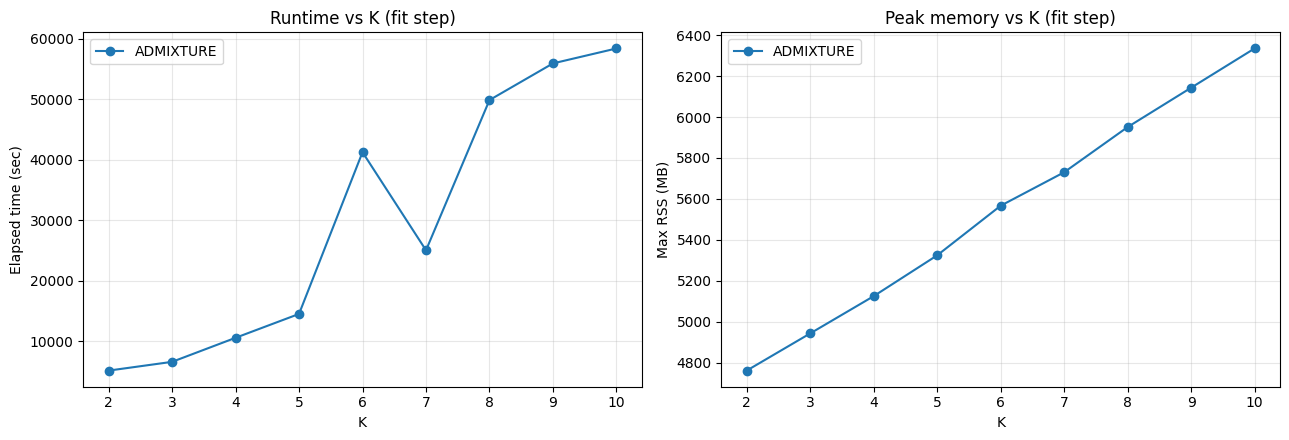

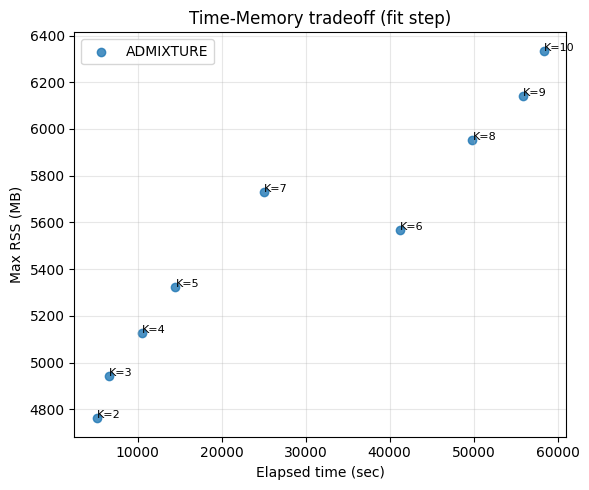

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

repo = Path.cwd()
adm_metrics_path = repo / "dump/admixture/metrics.tsv"
fst_metrics_path = repo / "dump/structure/metrics.tsv"

adm = pd.read_csv(adm_metrics_path, sep="\t")
fst = pd.read_csv(fst_metrics_path, sep="\t")

metrics = pd.concat([adm, fst], ignore_index=True)

# Keep successful runs only
metrics = metrics[metrics["exit_code"] == 0].copy()

# Numeric conversion (NA -> NaN)
for col in ["elapsed_sec", "user_cpu_sec", "sys_cpu_sec", "max_rss_kb"]:
    metrics[col] = pd.to_numeric(metrics[col], errors="coerce")

# Keep fit step with valid numeric K for method-to-method comparison
fit = metrics[(metrics["step"] == "fit")].copy()
fit["K_num"] = pd.to_numeric(fit["K"], errors="coerce")
fit = fit.dropna(subset=["K_num"])
fit["K_num"] = fit["K_num"].astype(int)

# Method naming for plotting
method_map = {"admixture": "ADMIXTURE", "faststructure": "fastSTRUCTURE"}
fit["method_label"] = fit["method"].map(method_map).fillna(fit["method"])

fit["total_cpu_sec"] = fit["user_cpu_sec"].fillna(0) + fit["sys_cpu_sec"].fillna(0)
fit["cpu_efficiency"] = fit["total_cpu_sec"] / fit["elapsed_sec"].replace(0, np.nan)
fit["max_rss_mb"] = fit["max_rss_kb"] / 1024

# Wide table for side-by-side comparison
pivot = fit.pivot_table(
    index="K_num",
    columns="method_label",
    values=["elapsed_sec", "max_rss_mb", "cpu_efficiency"],
    aggfunc="mean",
)

# Add relative metrics (fastSTRUCTURE / ADMIXTURE) where both exist
if {"ADMIXTURE", "fastSTRUCTURE"}.issubset(pivot["elapsed_sec"].columns):
    time_ratio = pivot[("elapsed_sec", "fastSTRUCTURE")] / pivot[("elapsed_sec", "ADMIXTURE")]
    mem_ratio = pivot[("max_rss_mb", "fastSTRUCTURE")] / pivot[("max_rss_mb", "ADMIXTURE")]
    ratio_df = pd.DataFrame({
        "time_ratio_fastSTRUCTURE_over_ADMIXTURE": time_ratio,
        "memory_ratio_fastSTRUCTURE_over_ADMIXTURE": mem_ratio,
    })
    display(ratio_df.round(3))

print("\n[Fit-step summary by method]")
summary = fit.groupby("method_label").agg(
    runs=("K_num", "count"),
    k_min=("K_num", "min"),
    k_max=("K_num", "max"),
    elapsed_mean_sec=("elapsed_sec", "mean"),
    elapsed_sum_sec=("elapsed_sec", "sum"),
    rss_mean_mb=("max_rss_mb", "mean"),
    rss_peak_mb=("max_rss_mb", "max"),
    cpu_eff_mean=("cpu_efficiency", "mean"),
).round(3)
display(summary)

print("\n[Per-K detailed table]")
detail = fit[["method_label", "K_num", "elapsed_sec", "max_rss_mb", "total_cpu_sec", "cpu_efficiency"]].sort_values(["K_num", "method_label"])
display(detail.round(3))

# ---------- Visualization ----------
# Line plots: over K
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
for method_label, g in fit.groupby("method_label"):
    g = g.sort_values("K_num")
    axes[0].plot(g["K_num"], g["elapsed_sec"], marker="o", label=method_label)
    axes[1].plot(g["K_num"], g["max_rss_mb"], marker="o", label=method_label)

axes[0].set_title("Runtime vs K (fit step)")
axes[0].set_xlabel("K")
axes[0].set_ylabel("Elapsed time (sec)")
axes[0].grid(True, alpha=0.3)

axes[1].set_title("Peak memory vs K (fit step)")
axes[1].set_xlabel("K")
axes[1].set_ylabel("Max RSS (MB)")
axes[1].grid(True, alpha=0.3)

for ax in axes:
    ax.legend()
plt.tight_layout()
plt.show()

# Scatter for time-memory tradeoff
plt.figure(figsize=(6, 5))
for method_label, g in fit.groupby("method_label"):
    plt.scatter(g["elapsed_sec"], g["max_rss_mb"], label=method_label, alpha=0.8)
    for _, row in g.iterrows():
        plt.text(row["elapsed_sec"], row["max_rss_mb"], f"K={row['K_num']}", fontsize=8)

plt.title("Time-Memory tradeoff (fit step)")
plt.xlabel("Elapsed time (sec)")
plt.ylabel("Max RSS (MB)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

## Qualitative Comparison on Global Ancestry Inference Results

### Visulization of Population Structure - All Autosomes

You can run our analysis code below to observe something interesting when exploring population structure.

**High-Level Consistency**: Both models successfully identify the major continental clusters that correspond to the 1000 Genomes Project populations. Even as $K$ increases, the "backbone" of the population structure remains stable. For instance, European (EUR) groups such as CEU, GBR, and IBS show high consistency, while ASW and ACB (African Americans/Caribbeans) exhibit complex admixture patterns.

**fastSTRUCTURE with less noise**: fastSTRUCTURE tends to produce **cleaner** looking plots with less background noise. This is because its underlying variational Bayesian framework often forces individuals toward 0 or 1 membership unless there is strong evidence for admixture. In contrast, Admixture model appears more sensitive to subtle gene flow. You can see more **noise** or low-level components across almost all individuals, which often reflects actual historical interbreeding rather than just mathematical artifacts.

**The "Splitter" Effect**: As you move from $K=4$ to $K=8$, you can observe how a single ancestral component in one population (e.g., YRI group) begins to fragment into two distinct sub-components, indicating finer-scale sub-structure within that geographic region.

Combined membership plot saved to: dump/admixture/plots/combined_membership_panels.png


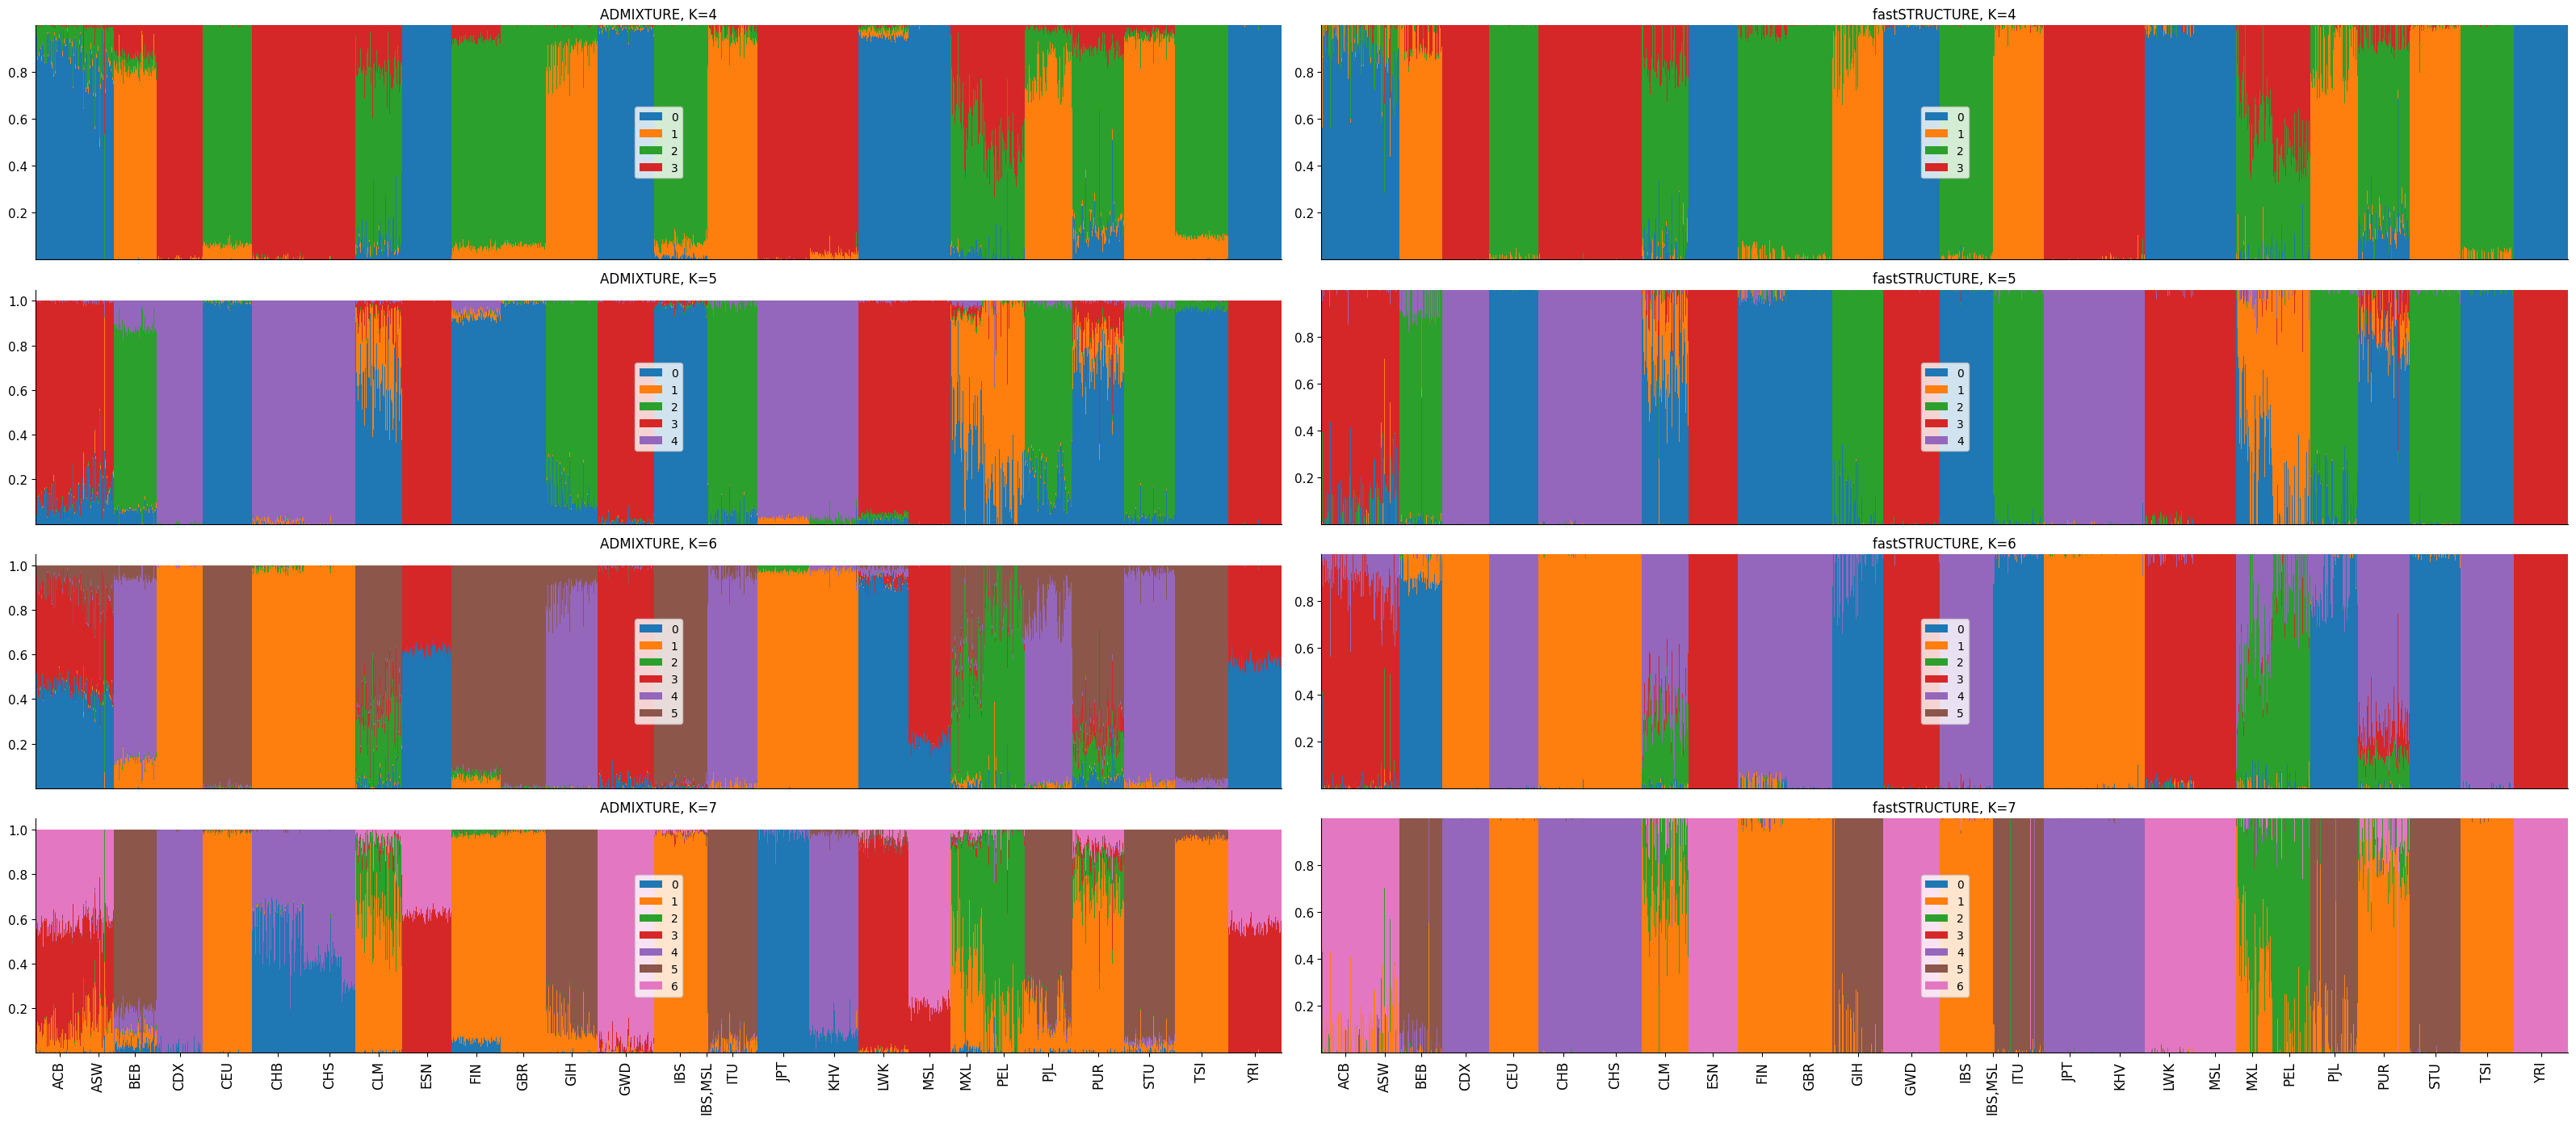

PosixPath('dump/admixture/plots/combined_membership_panels.png')

In [12]:
plot_combined_membership_panels(
    fam_path=plink_file(BASELINE_DATASET_PREFIX, ".fam"),
    panels_config=[
        {
            "data_path_template": (
                f"{BASELINE_RESULT['admixture_out_dir']}/"
                f"{BASELINE_RESULT['admixture_prefix']}_ALL.pruned.{{K}}.Q"
            ),
            "title_prefix": "ADMIXTURE",
        },
        {
            "data_path_template": "dump/structure/structure_ALL/fS_run_K.{K}.meanQ",
            "title_prefix": "fastSTRUCTURE",
            "reference_data_path_template": "dump/admixture/common_ALL.pruned.{K}.Q",
        },
    ],
)

### Visulization of Population Structure - Chromosome 20

Membership plot saved to: dump/special_chr20_maf001_pruned/admixture/plots/admixture_chr20_raw_vcf_maf_0_01_ld_prune_membership_panels.png
Membership plot saved to: dump/special_chr20_maf001_pruned/admixture/plots/admixture_chr20_raw_vcf_maf_0_01_ld_prune_membership_panels.pdf


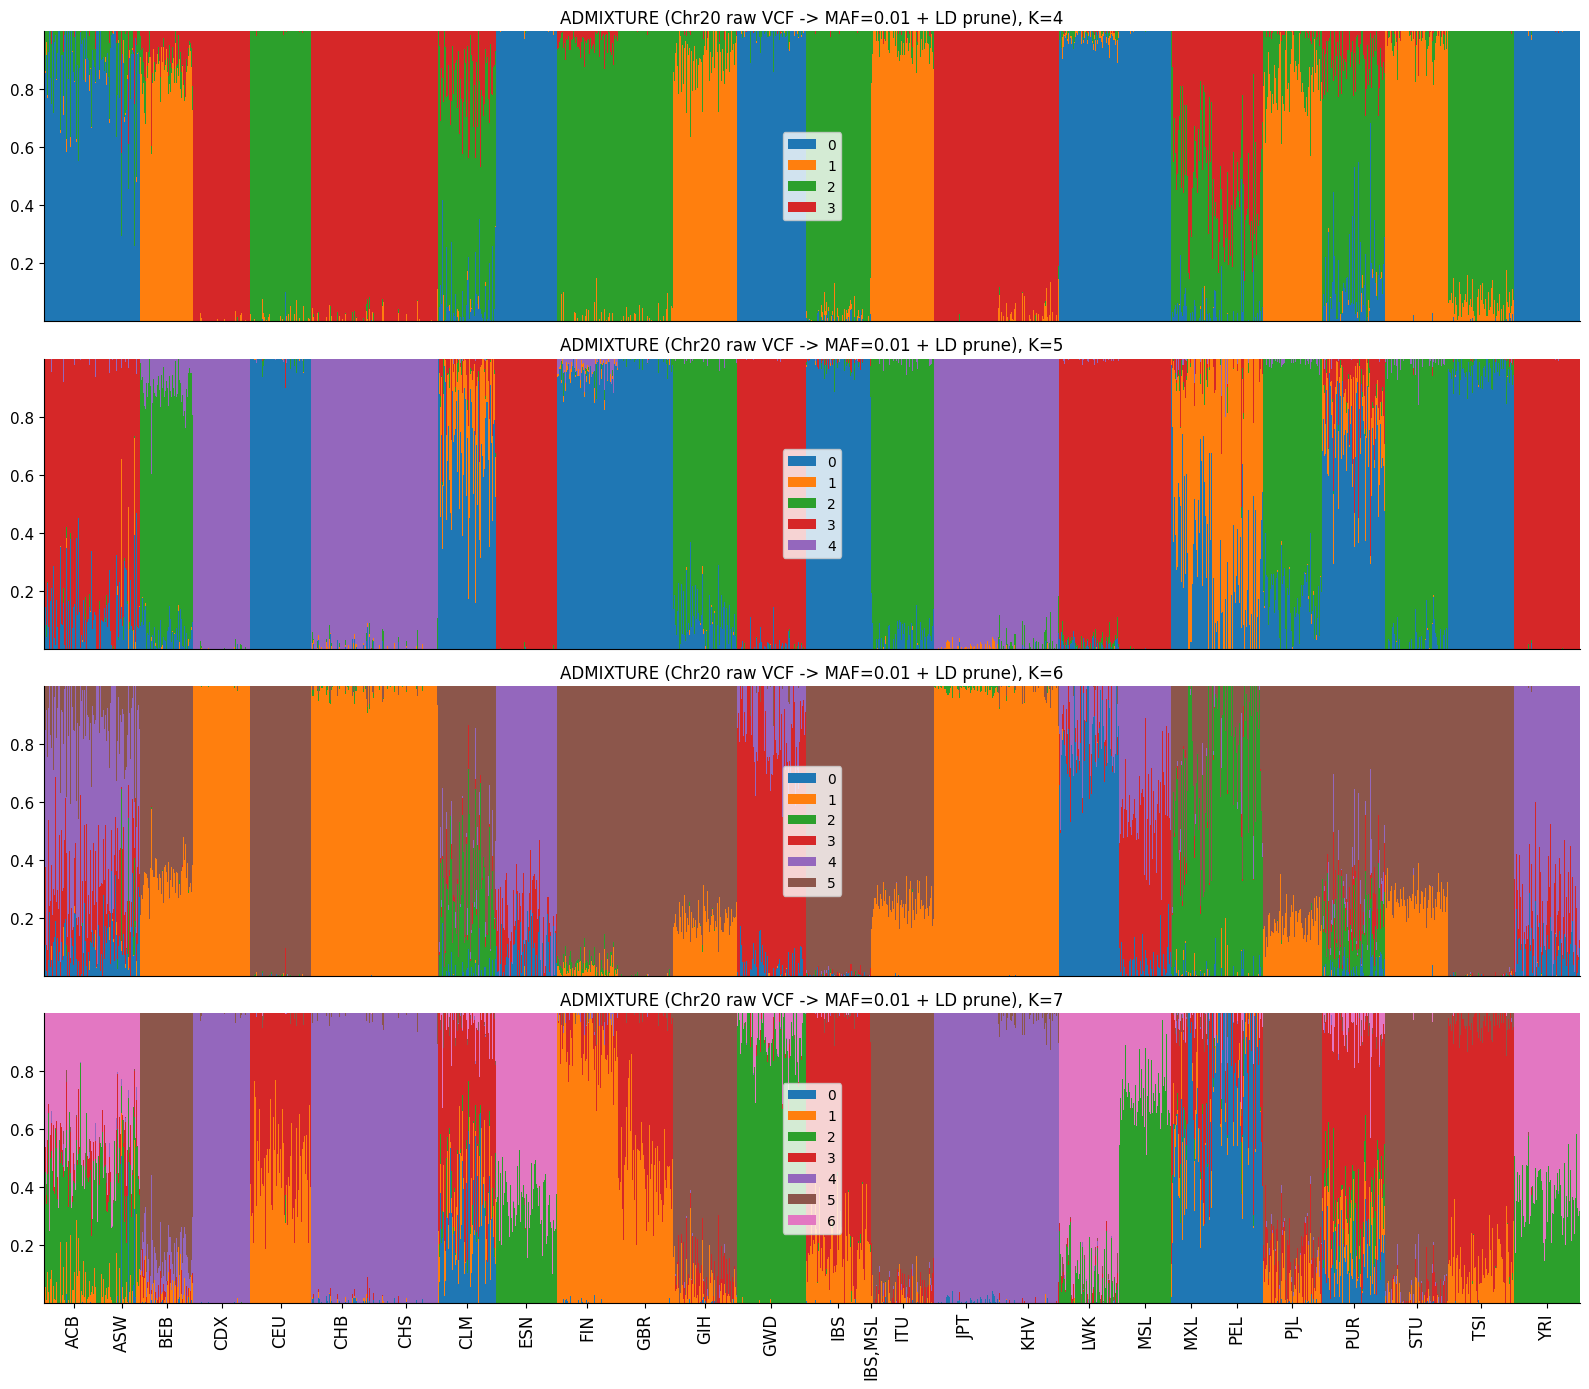

Membership plot saved to: dump/special_chr20_maf001_pruned/structure/structure_chr20_maf001_pruned_ALL/plots/faststructure_chr20_raw_vcf_maf_0_01_ld_prune_membership_panels.png
Membership plot saved to: dump/special_chr20_maf001_pruned/structure/structure_chr20_maf001_pruned_ALL/plots/faststructure_chr20_raw_vcf_maf_0_01_ld_prune_membership_panels.pdf


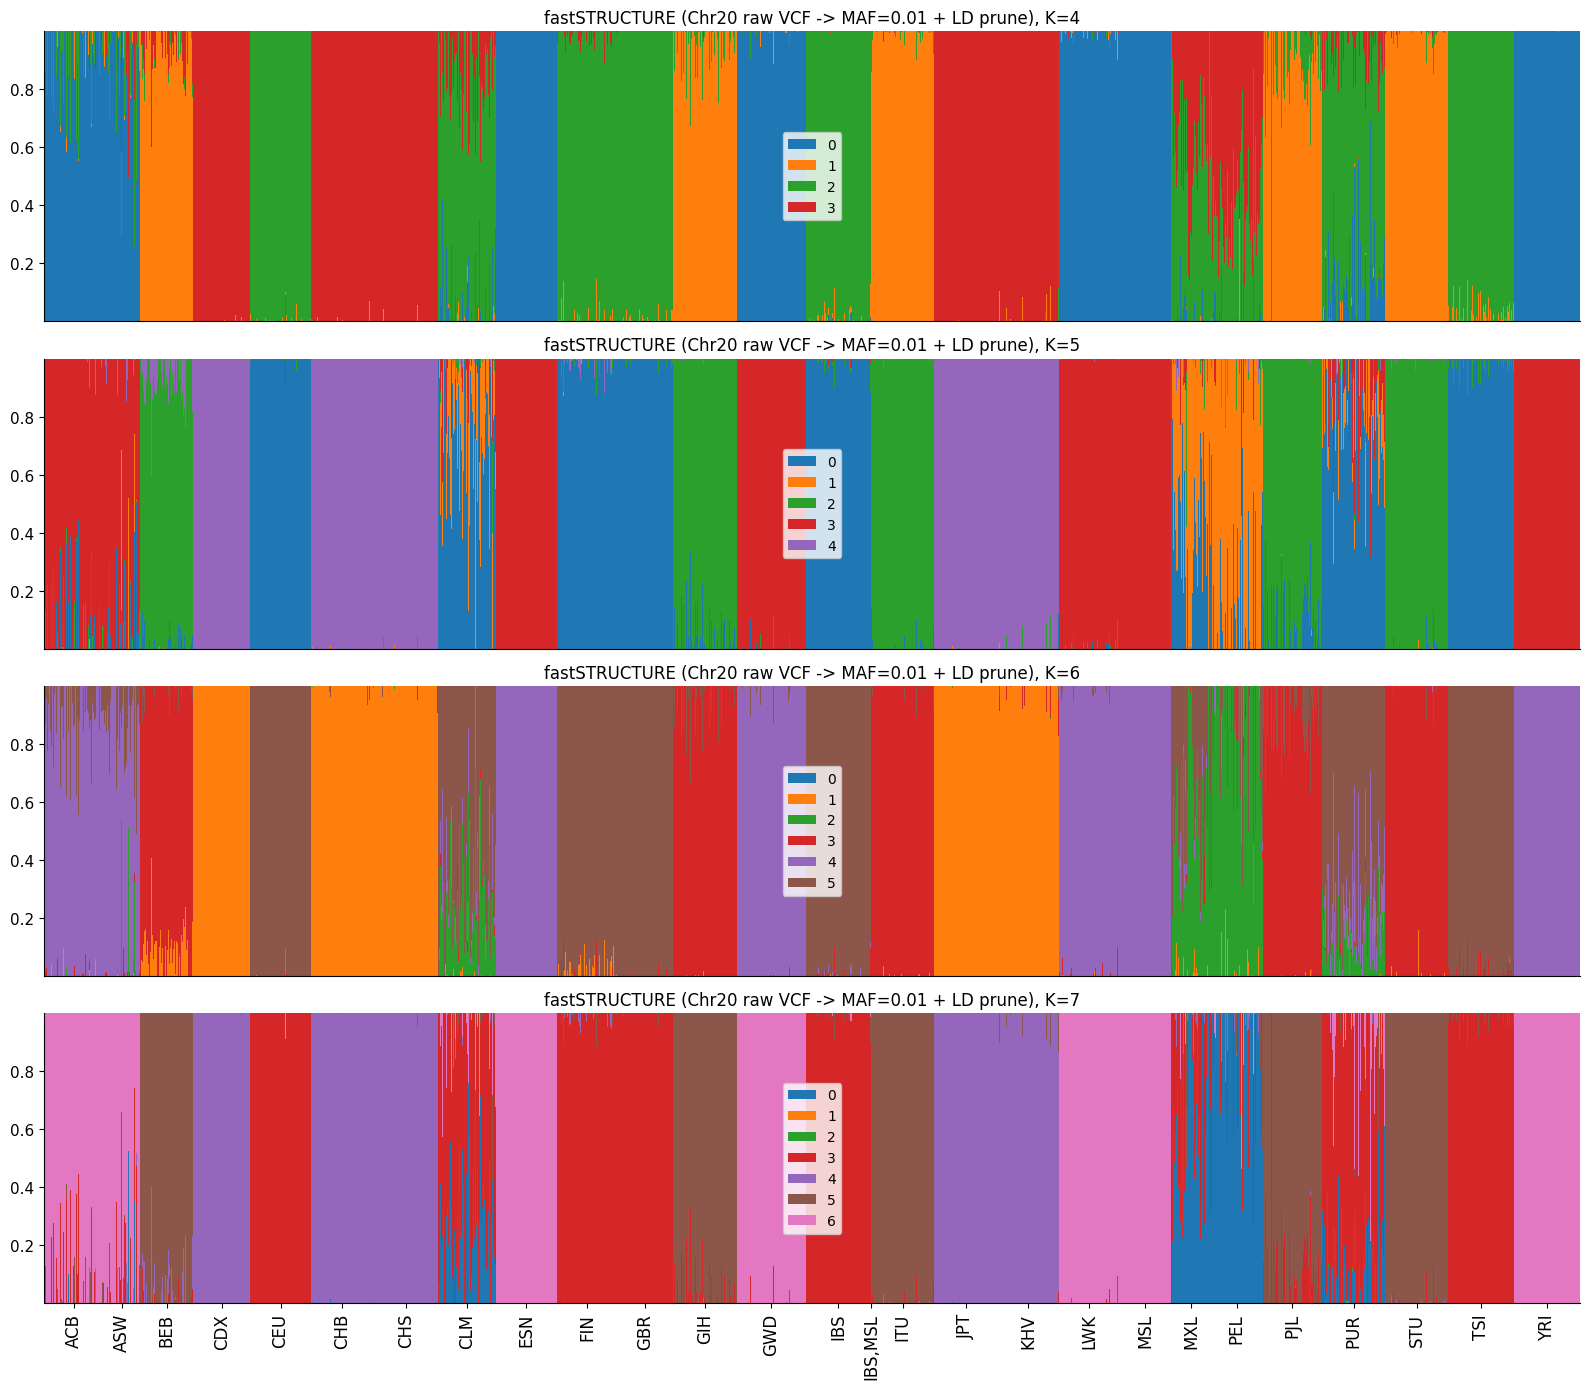

Membership plot saved to: dump/special_chr20_maf0005_pruned/admixture/plots/admixture_chr20_raw_vcf_maf_0_005_ld_prune_membership_panels.png
Membership plot saved to: dump/special_chr20_maf0005_pruned/admixture/plots/admixture_chr20_raw_vcf_maf_0_005_ld_prune_membership_panels.pdf


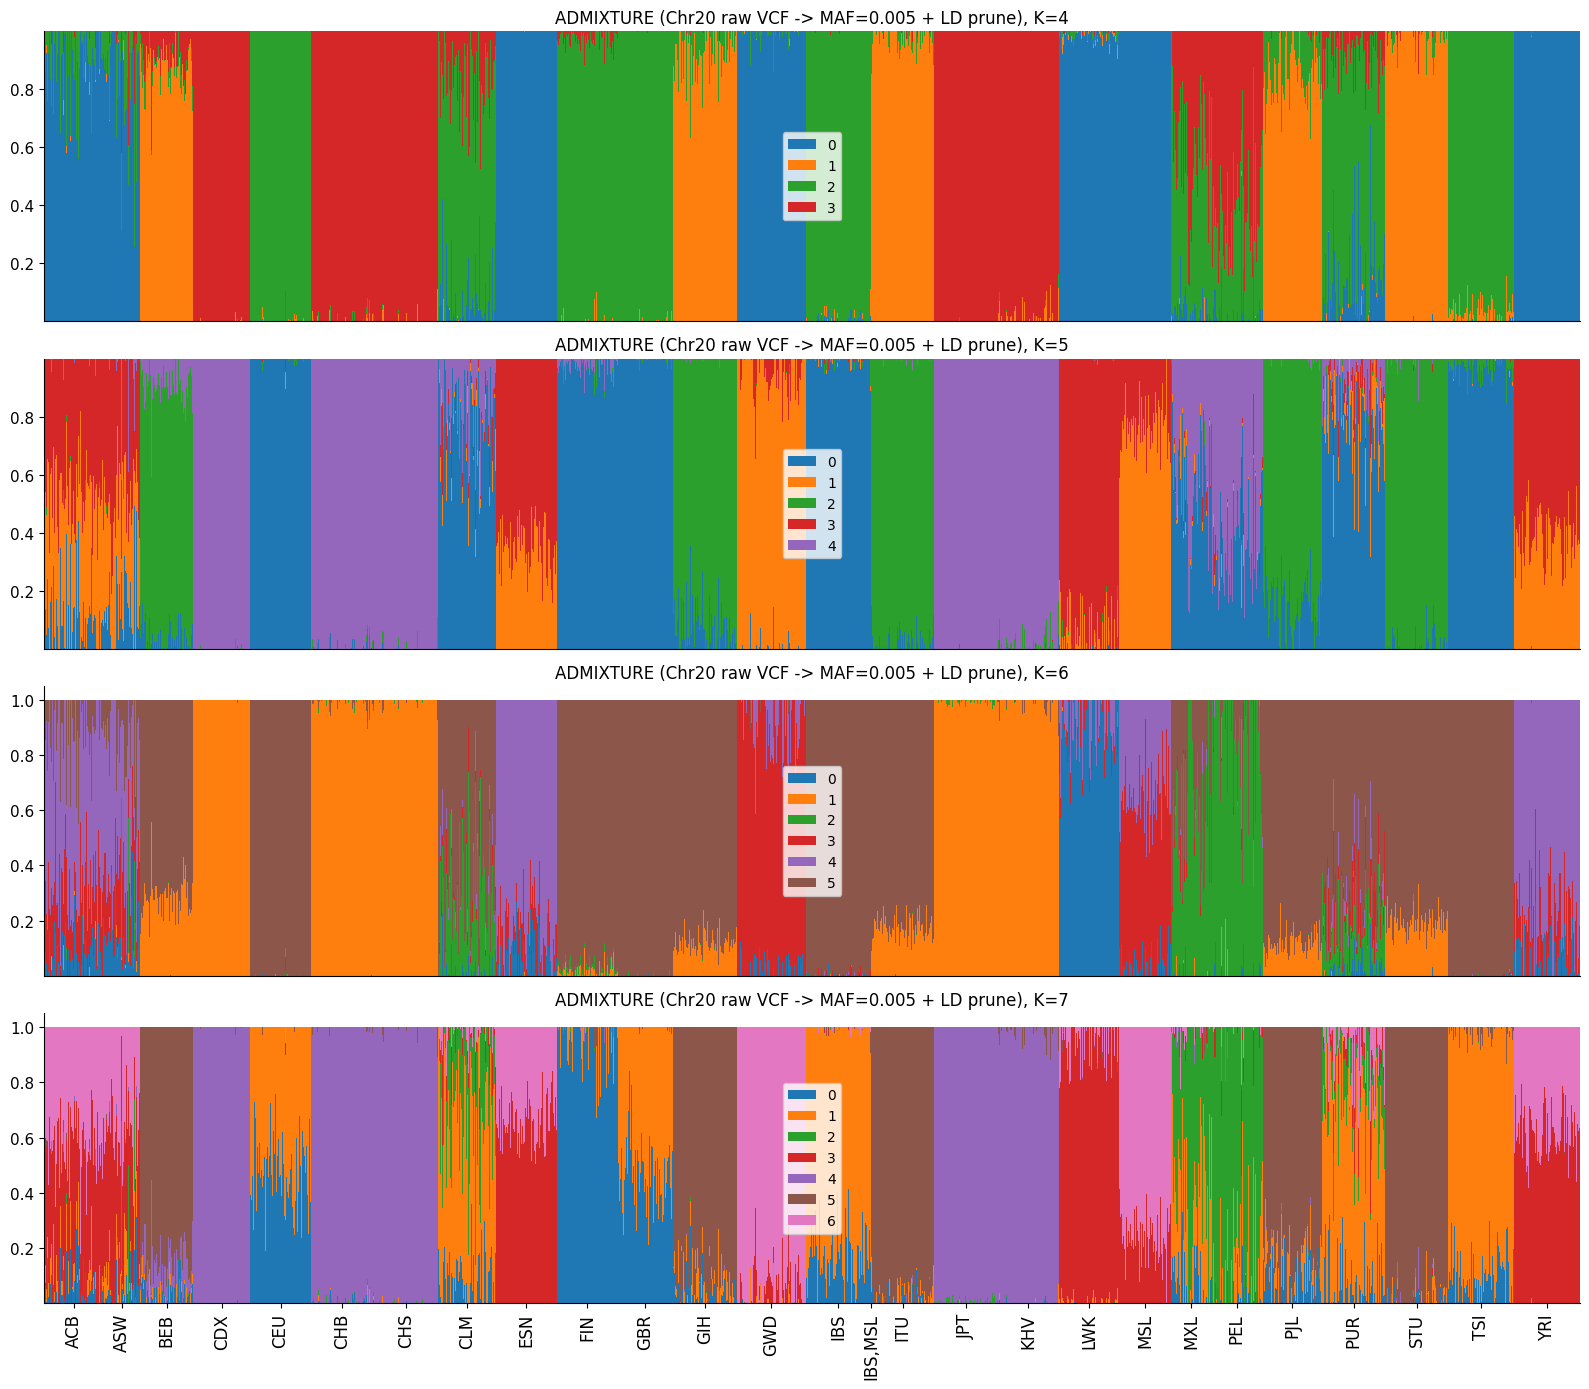

Membership plot saved to: dump/special_chr20_maf0005_pruned/structure/structure_chr20_maf0005_pruned_ALL/plots/faststructure_chr20_raw_vcf_maf_0_005_ld_prune_membership_panels.png
Membership plot saved to: dump/special_chr20_maf0005_pruned/structure/structure_chr20_maf0005_pruned_ALL/plots/faststructure_chr20_raw_vcf_maf_0_005_ld_prune_membership_panels.pdf


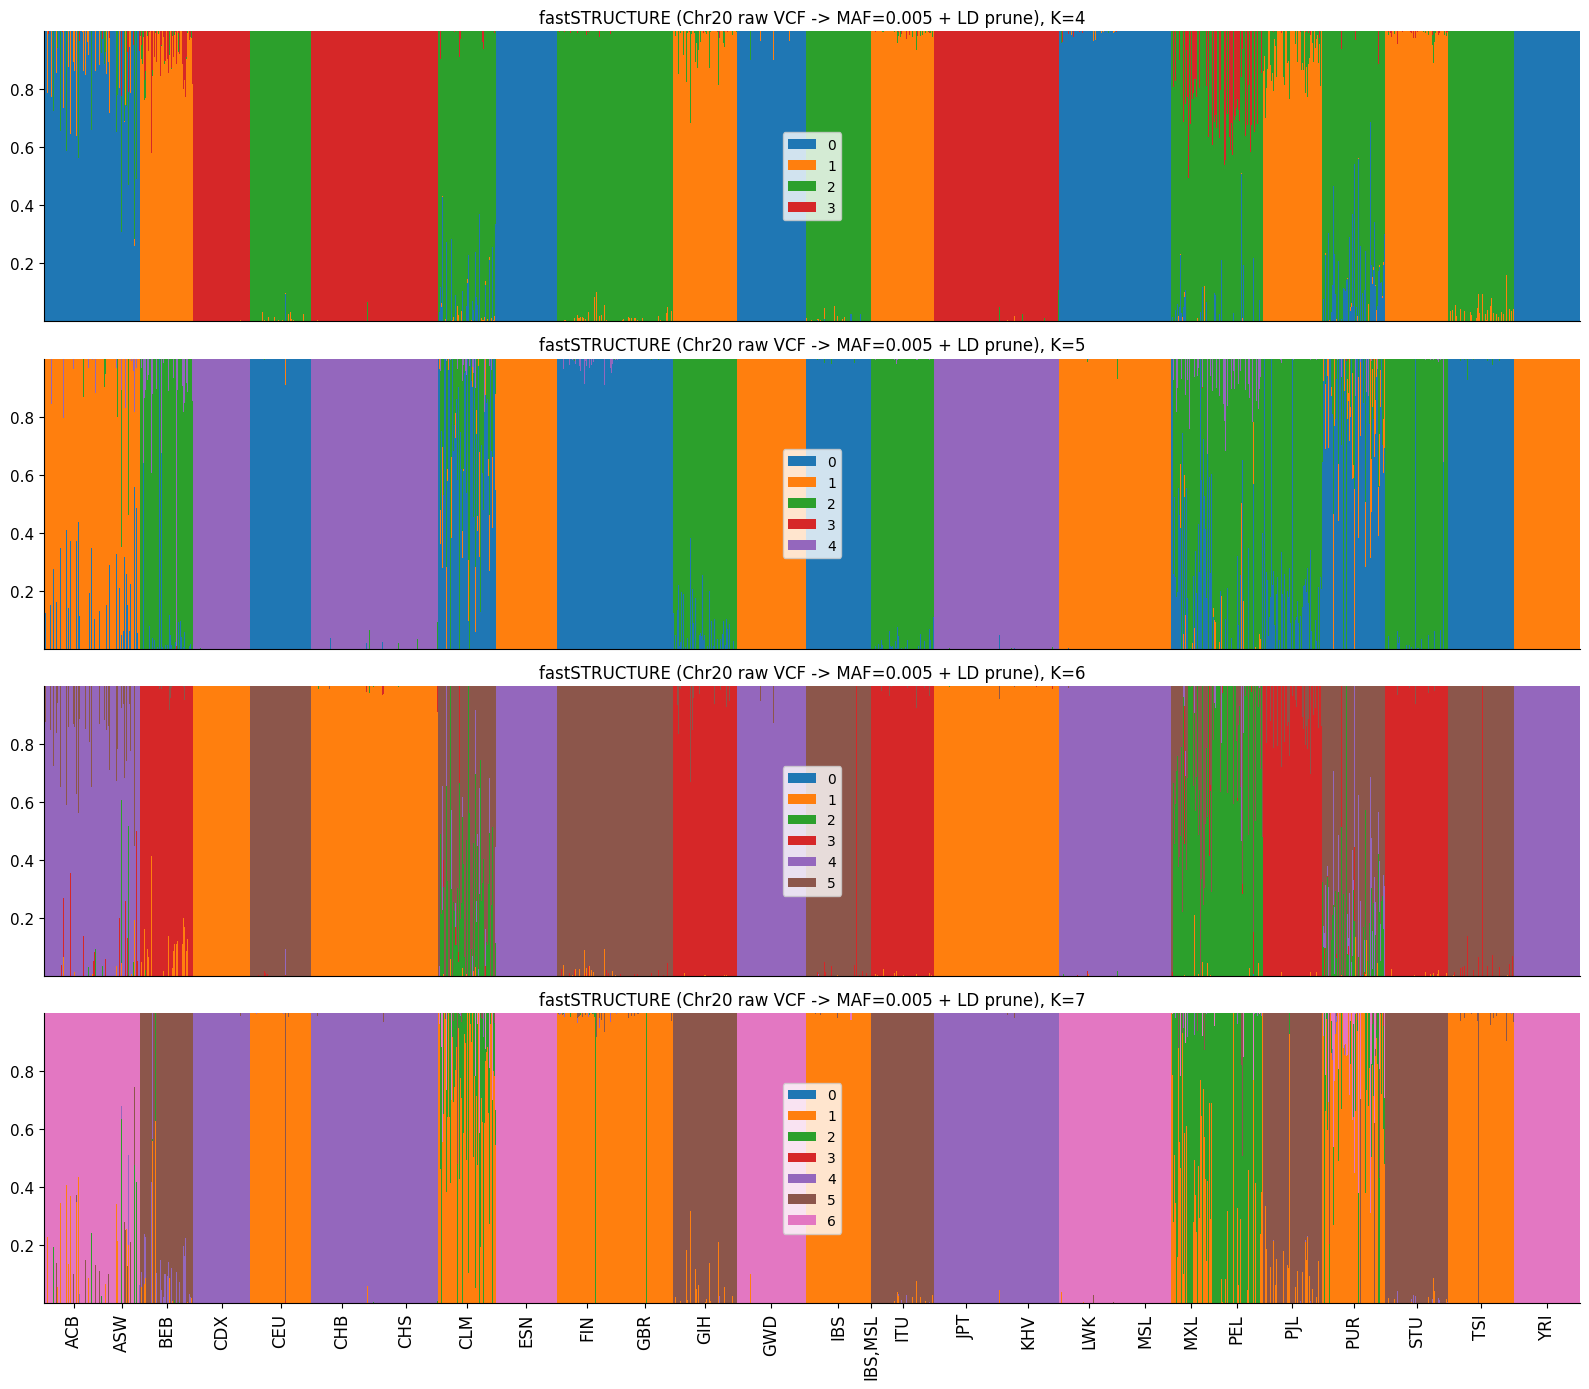

Membership plot saved to: dump/special_chr20_maf005_pruned/admixture/plots/admixture_chr20_raw_vcf_maf_0_05_ld_prune_membership_panels.png
Membership plot saved to: dump/special_chr20_maf005_pruned/admixture/plots/admixture_chr20_raw_vcf_maf_0_05_ld_prune_membership_panels.pdf


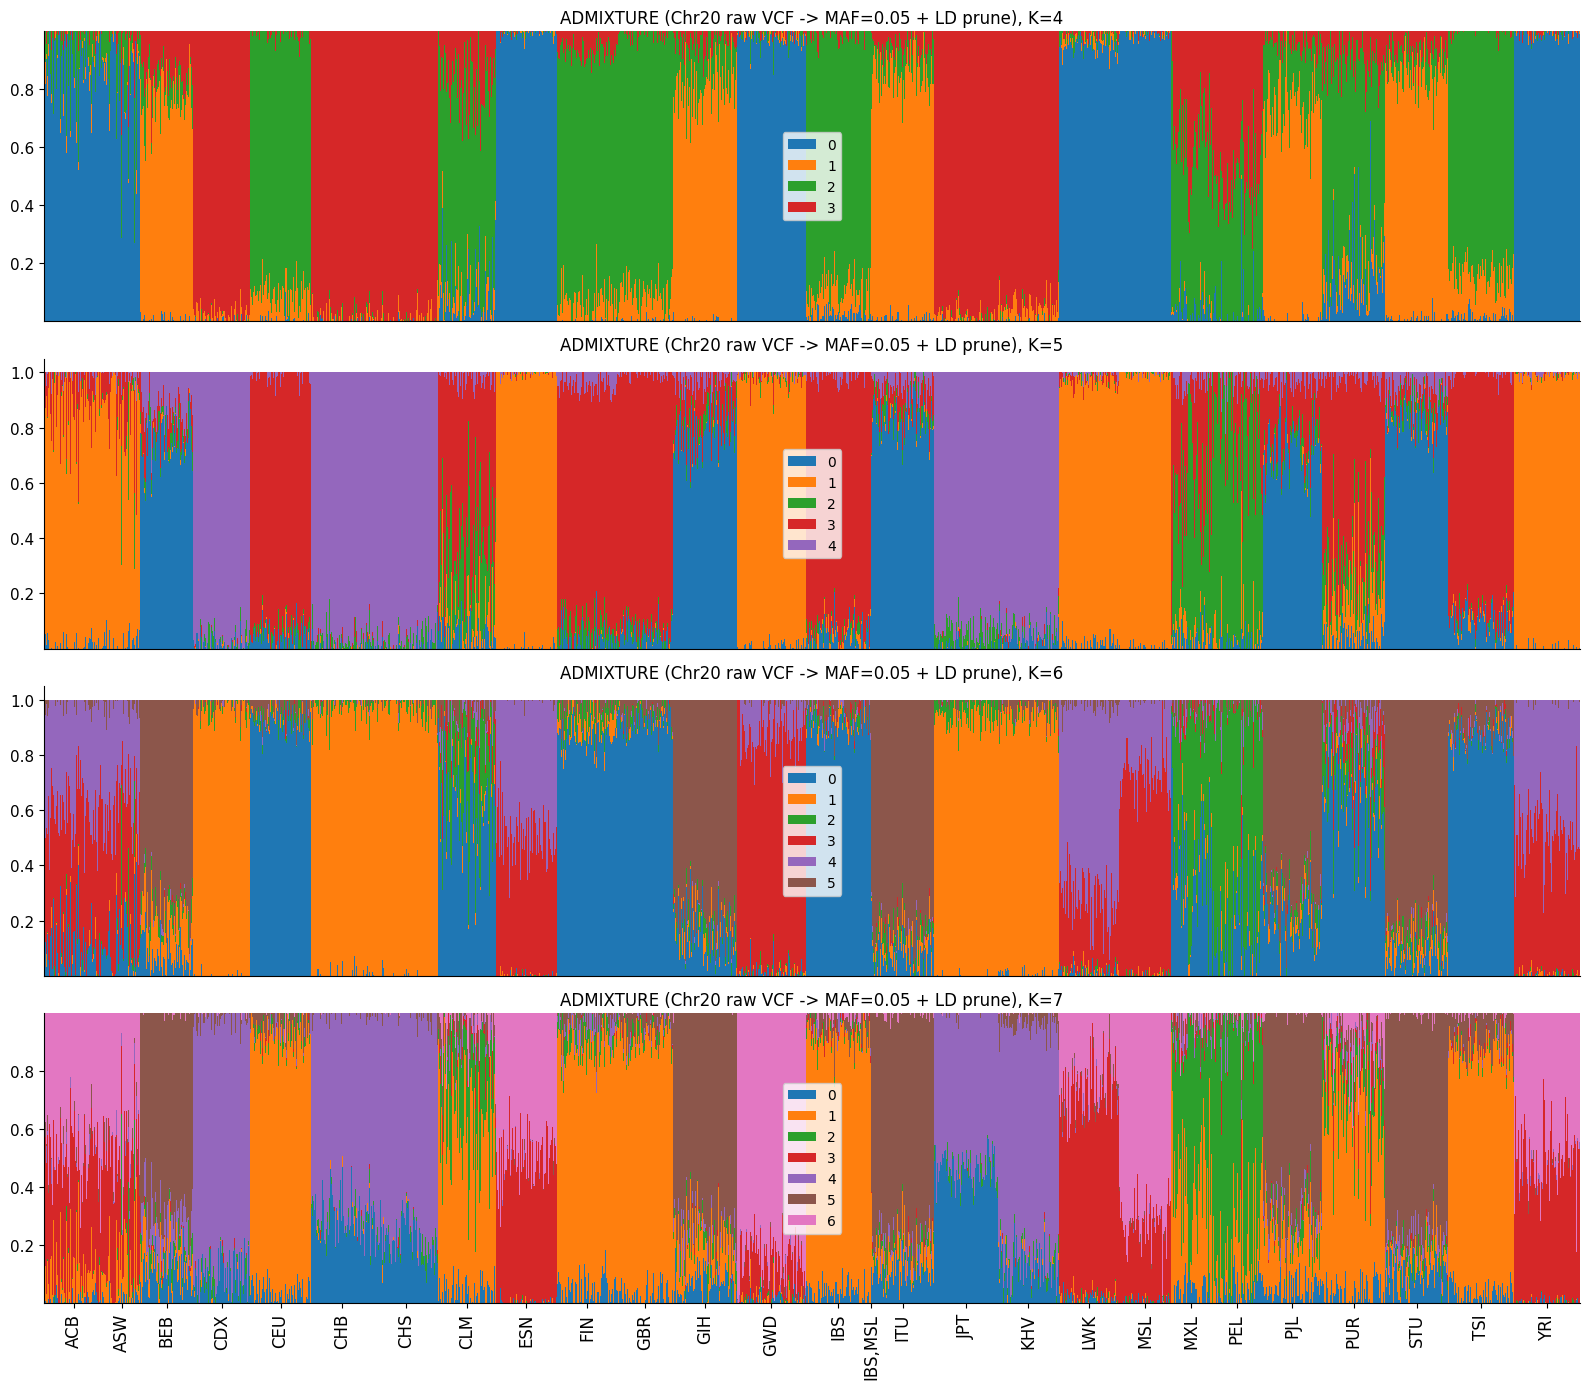

Membership plot saved to: dump/special_chr20_maf005_pruned/structure/structure_chr20_maf005_pruned_ALL/plots/faststructure_chr20_raw_vcf_maf_0_05_ld_prune_membership_panels.png
Membership plot saved to: dump/special_chr20_maf005_pruned/structure/structure_chr20_maf005_pruned_ALL/plots/faststructure_chr20_raw_vcf_maf_0_05_ld_prune_membership_panels.pdf


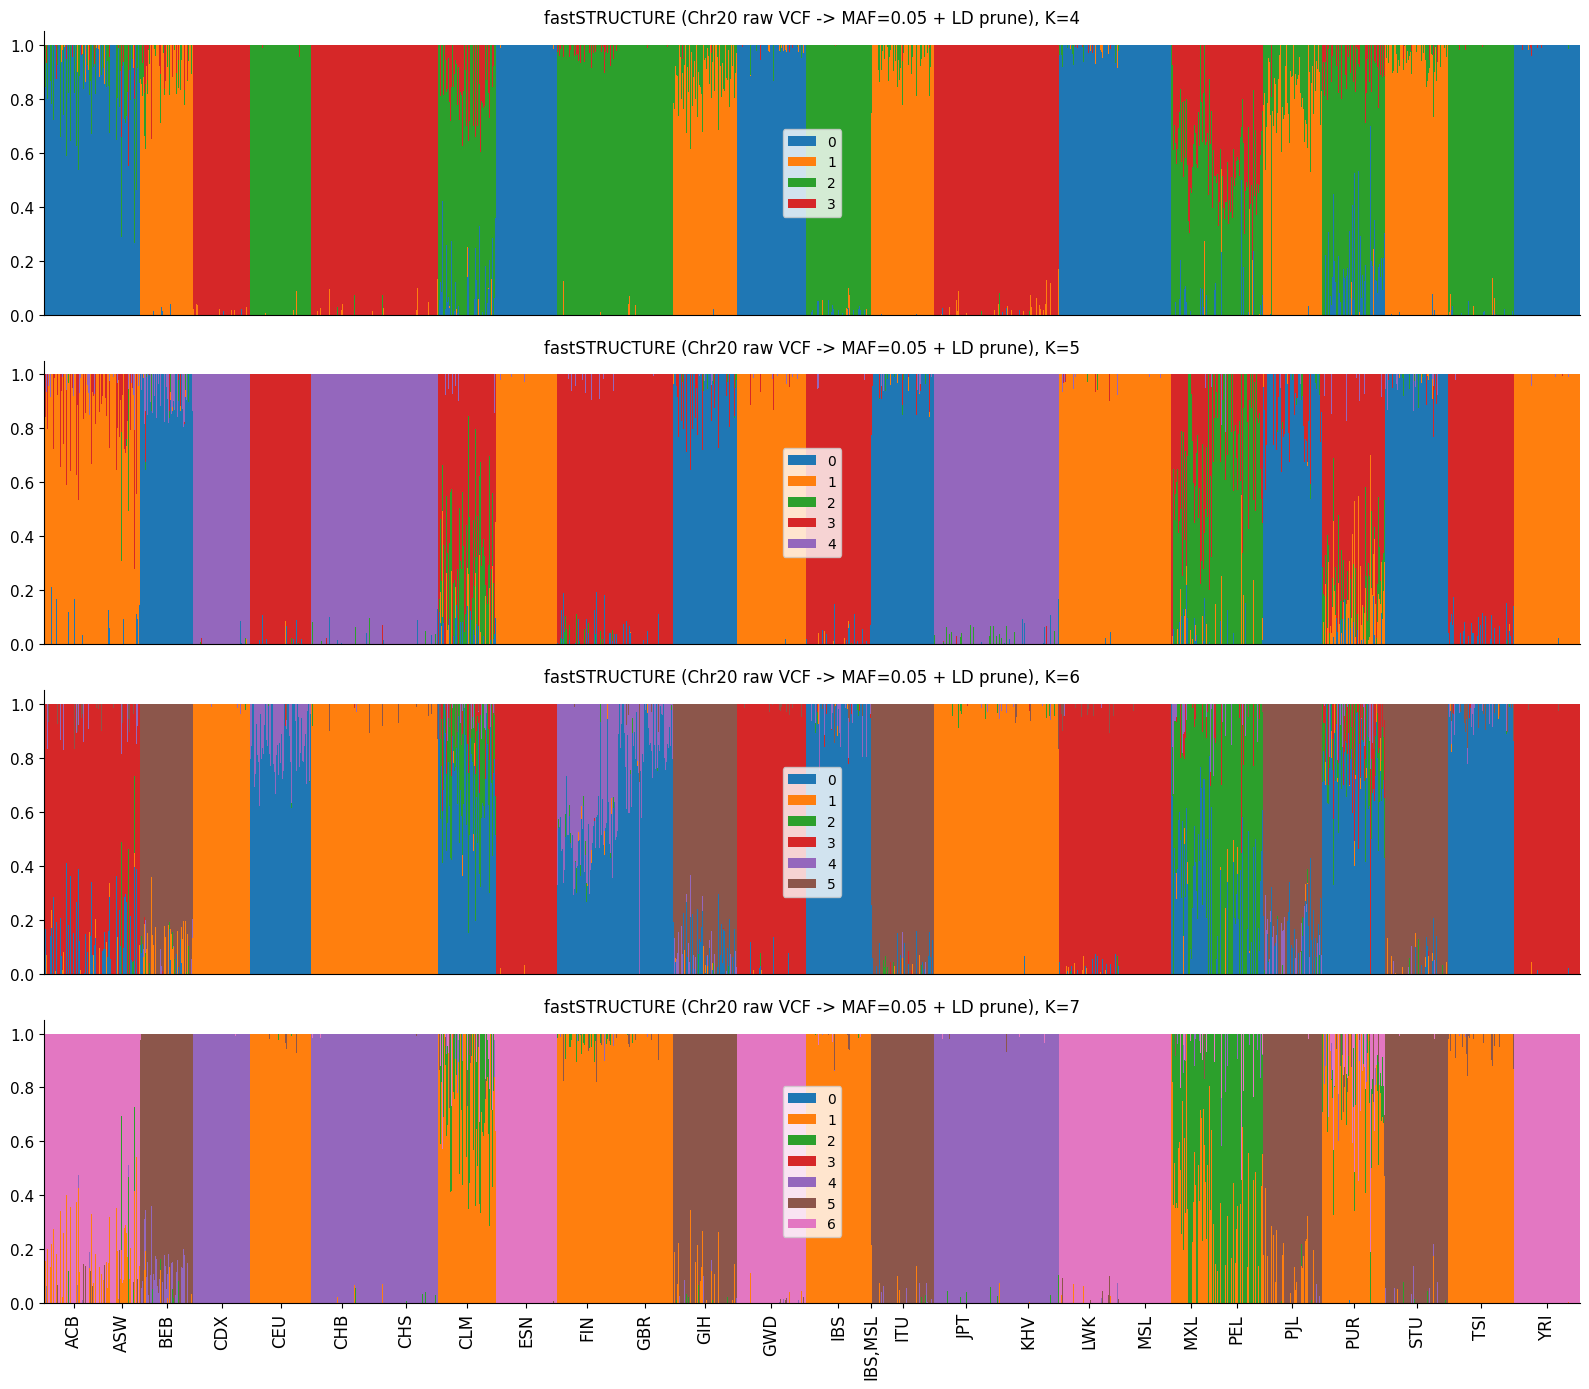

Membership plot saved to: dump/special_chr20_maf001_no_ld/admixture/plots/admixture_chr20_raw_vcf_maf_0_01_without_ld_prune_membership_panels.png
Membership plot saved to: dump/special_chr20_maf001_no_ld/admixture/plots/admixture_chr20_raw_vcf_maf_0_01_without_ld_prune_membership_panels.pdf


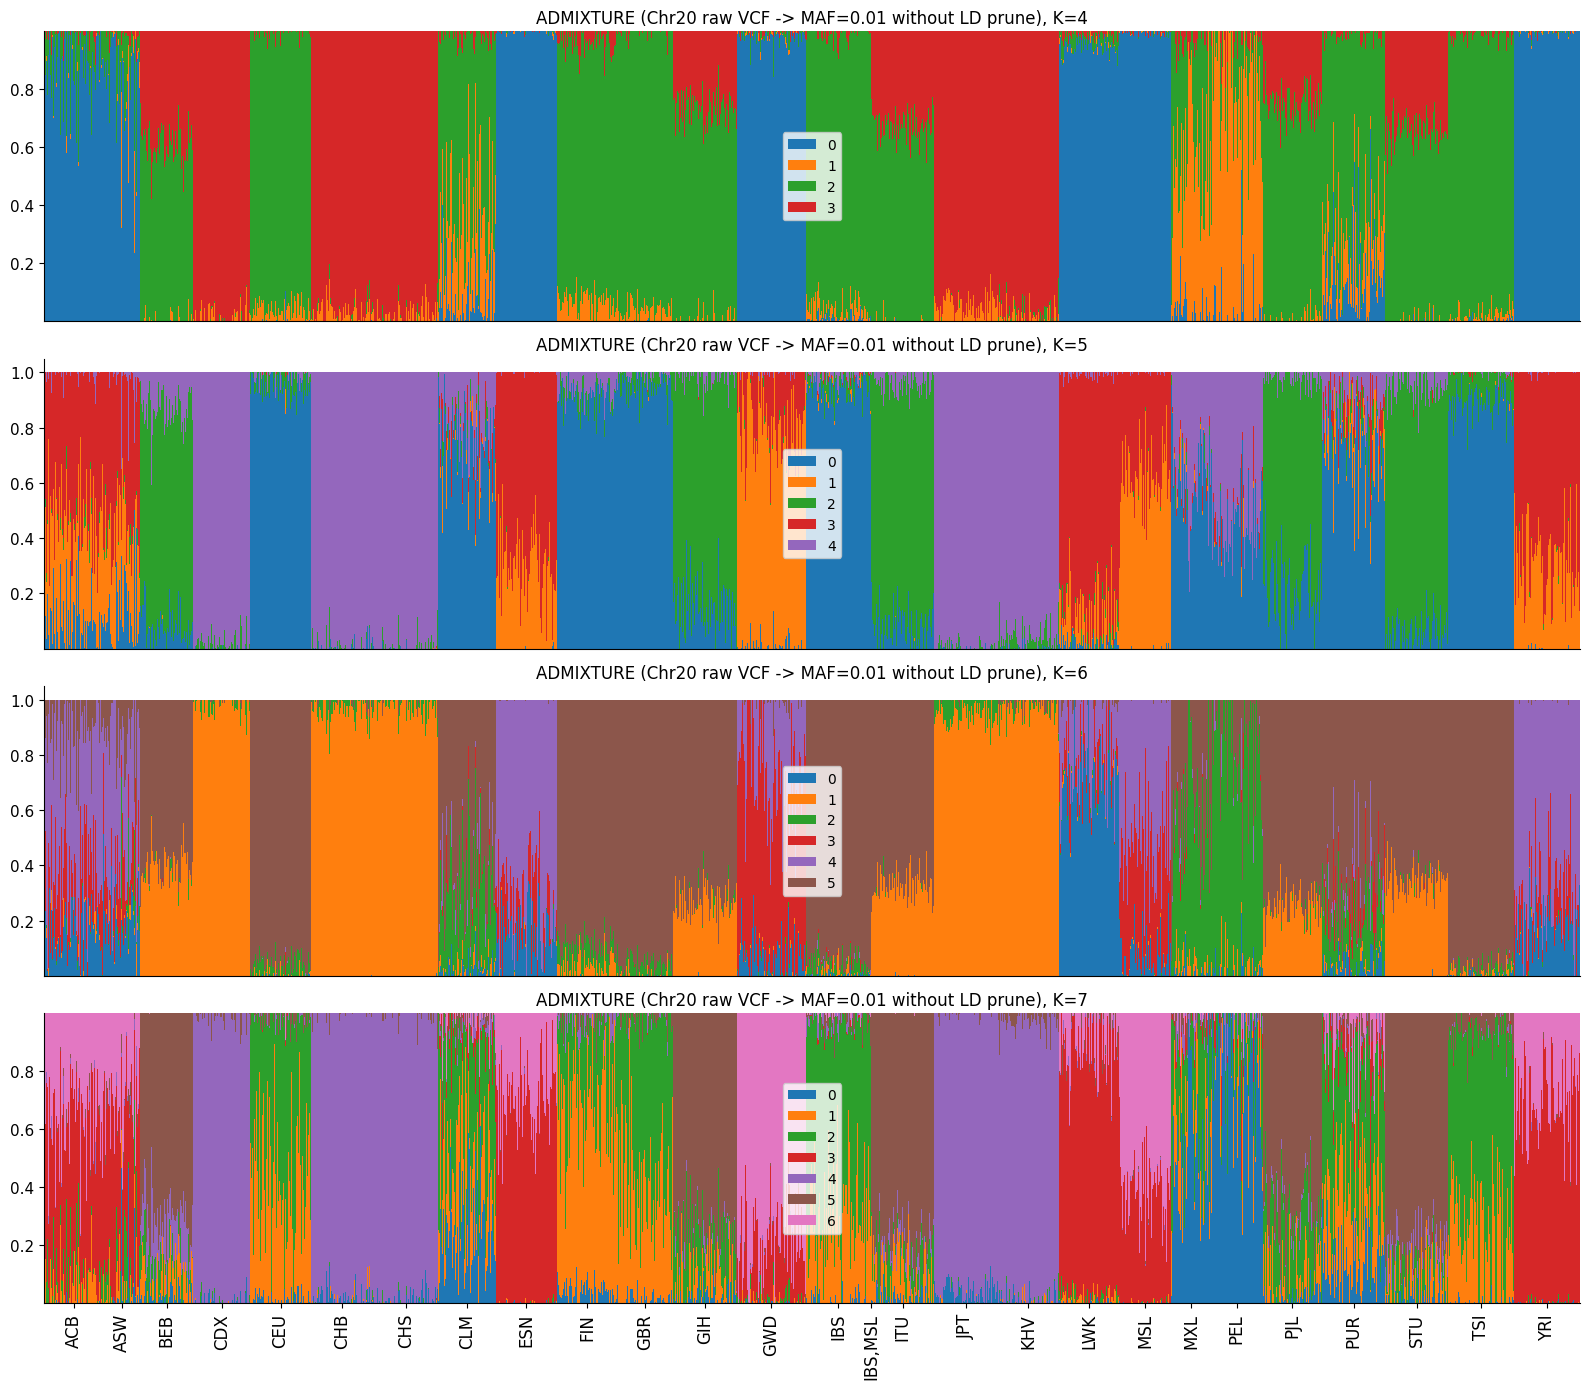

Membership plot saved to: dump/special_chr20_maf001_no_ld/structure/structure_chr20_maf001_no_ld_ALL/plots/faststructure_chr20_raw_vcf_maf_0_01_without_ld_prune_membership_panels.png
Membership plot saved to: dump/special_chr20_maf001_no_ld/structure/structure_chr20_maf001_no_ld_ALL/plots/faststructure_chr20_raw_vcf_maf_0_01_without_ld_prune_membership_panels.pdf


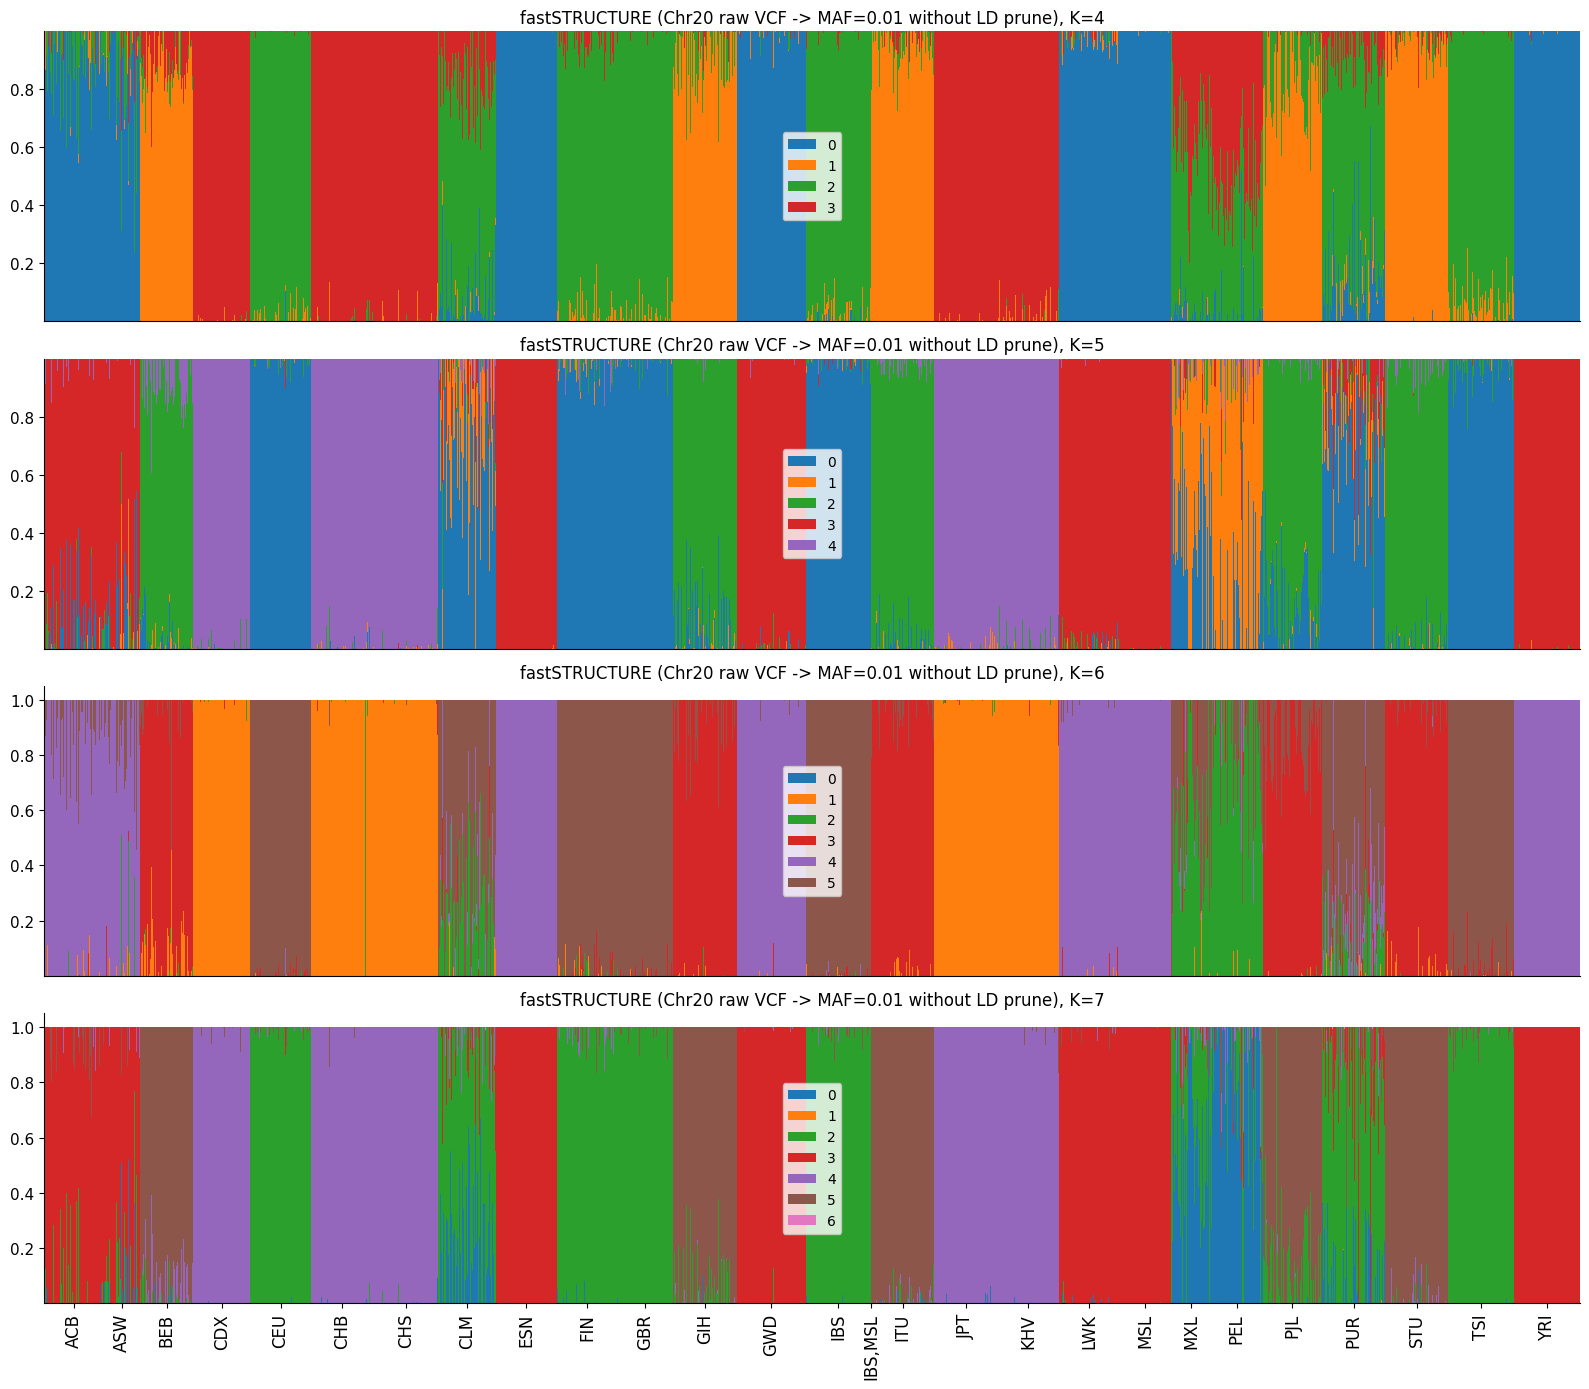

In [13]:
for spec in SPECIAL_EXPERIMENT_SPECS:
    if spec["name"] == "chr1_maf0005_pruned":
        continue
    result = SPECIAL_RESULTS[spec["name"]]
    dataset_name = Path(result["dataset_prefix"]).name
    admixture_template = f"{result['admixture_out_dir']}/{dataset_name}.{{K}}.Q"
    plot_membership_panels(
        fam_path=plink_file(result["dataset_prefix"], ".fam"),
        data_path_template=admixture_template,
        title_prefix=f"ADMIXTURE ({result['title']})",
    )
    plot_membership_panels(
        fam_path=plink_file(result["dataset_prefix"], ".fam"),
        data_path_template=f"{result['structure_out_dir']}/{result['structure_prefix']}_ALL/fS_run_K.{{K}}.meanQ",
        title_prefix=f"fastSTRUCTURE ({result['title']})",
        reference_data_path_template=admixture_template,
    )

## Quantitative Comparison on Global Ancestry Inference Results

### K-value Evaluation

To determine the optimal number of ancestral populations ($K$), we evaluated two different metrics across a range of $K$ values (from 2 to 10). Choosing the "right" $K$ involves identifying the point where model fit improves significantly before hitting diminishing returns.

#### Methodology and Metrics
- ADMIXTURE (Cross-Validation Error): 
We utilized 10-fold cross-validation. In this metric, a lower CV error indicates a better-supported $K$ value, as it suggests the model has better predictive power.
- fastSTRUCTURE (Marginal Likelihood): We measured the model's marginal likelihood. In this case, a higher (less negative) value indicates a more probable $K$ for the given dataset.

#### Results and Interpretation
Based on the generated plots, we observed the following:

- ADMIXTURE: The CV error decreases sharply from $K=2$ to $K=5$. After $K=5$, the rate of decrease slows down significantly, suggesting that additional clusters beyond this point add marginal explanatory power.

- fastSTRUCTURE: The marginal likelihood shows an evident peak and "elbow" at $K=5/6$.

Based on the combined evidence from both tools—specifically the sharp decline in CV error and the plateau in marginal likelihood—we have selected $K = 4, 5, 6, \text{and } 7$ as the candidate values for further population structure analysis. 
<!-- These values capture the primary levels of genetic differentiation without over-partitioning the data. -->

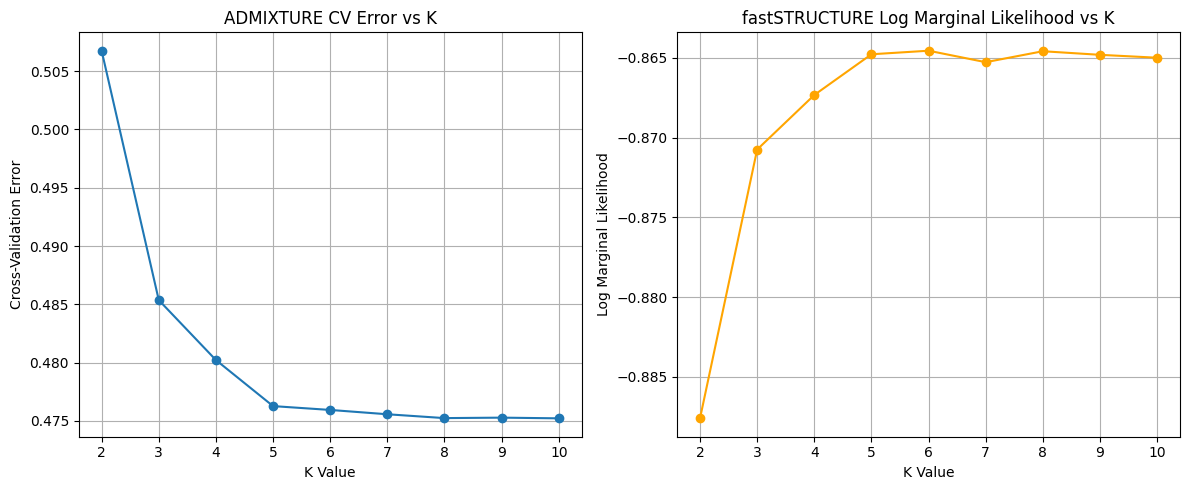

In [14]:
import matplotlib.pyplot as plt
import re
from pathlib import Path

repo = Path.cwd()

# Load ADMIXTURE CV errors from output file
cv_path = repo / "dump" / "admixture" / "cv_results.txt"
cv_pairs = []
for line in cv_path.read_text().strip().splitlines():
    k_str, cv_str = line.split()
    cv_pairs.append((int(k_str), float(cv_str)))
cv_pairs.sort(key=lambda x: x[0])


def extract_marginal_likelihood(log_path: Path) -> float:
    text = log_path.read_text()
    match = re.search(r"Marginal Likelihood =\s*([-+]?\d*\.?\d+(?:[eE][-+]?\d+)?)", text)
    if match is None:
        raise ValueError(f"Cannot find marginal likelihood in {log_path}")
    return float(match.group(1))


# Load fastSTRUCTURE marginal likelihoods from per-K logs
ml_pairs = []
for k, _ in cv_pairs:
    log_path = repo / "dump" / "structure" / "structure_ALL" / f"fS_run_K.{k}.log"
    ml_pairs.append((k, extract_marginal_likelihood(log_path)))

k_values = [k for k, _ in cv_pairs]
cv_errors = [value for _, value in cv_pairs]
ml = [value for _, value in ml_pairs]

# Create two subplots (1 row, 2 columns)
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# ----- Subplot 1: ADMIXTURE CV error -----
axes[0].plot(k_values, cv_errors, marker='o')
axes[0].set_xlabel("K Value")
axes[0].set_ylabel("Cross-Validation Error")
axes[0].set_title("ADMIXTURE CV Error vs K")
axes[0].set_xticks(k_values)
axes[0].grid(True)

# ----- Subplot 2: fastSTRUCTURE Marginal Likelihood -----
axes[1].plot(k_values, ml, marker='o', color='orange')
axes[1].set_xlabel("K Value")
axes[1].set_ylabel("Log Marginal Likelihood")
axes[1].set_title("fastSTRUCTURE Log Marginal Likelihood vs K")
axes[1].set_xticks(k_values)
axes[1].grid(True)

plt.tight_layout()
plt.show()

### Superpopulation Hard Classification

The 1000 Genomes project provides 5 **superpopulation labels** (AFR / AMR / EAS / EUR / SAS) for each individual. Although they are not mixture proportion continuous ground truths, they serve as an external reference for evaluating whether the inferred ancestry assignment is consistent with known population structure.

**Approach:**

0. Consider K = 5 as there are 5 superpopulations.
1. For each individual $i$, take the *hard assignment* $\hat{k}_i = \arg\max_k Q_{ik}$.
2. For each component $k$, identify its plurality superpopulation (the super-pop most common among individuals whose hard assignment is $k$).
3. Map each individual's hard-assignment component to its plurality superpopulation label and compare against the real superpopulation label.
4. Report **accuracy** and **macro-F1** only.

In [15]:

import re
import numpy as np
import pandas as pd
from sklearn.metrics import f1_score

SUPER_POPS = ["AFR", "AMR", "EAS", "EUR", "SAS"]
K = 5

_SPLIT = re.compile(r"[,\|;/\s]+")

def parse_superpops(x):
    if x is None or pd.isna(x):
        return []
    parts = [p.strip() for p in _SPLIT.split(str(x).strip()) if p.strip()]
    out = [p for p in parts if p in SUPER_POPS]
    seen, out2 = set(), []
    for p in out:
        if p not in seen:
            out2.append(p); seen.add(p)
    return out2

def hard_assign(Q):
    return np.argmax(Q, axis=1)

def component_to_superpop_multilabel(assignments, true_sets, K):
    comp_map = {}
    for k in range(K):
        m = (assignments == k)
        if not np.any(m):
            comp_map[k] = "NA"
            continue
        counts = pd.Series(0, index=SUPER_POPS, dtype=int)
        for labs in np.array(true_sets, dtype=object)[m]:
            for sp in labs:
                counts[sp] += 1
        comp_map[k] = counts.idxmax() if counts.sum() > 0 else "NA"
    return comp_map

def multilabel_crosstab(true_sets, y_pred):
    rows = []
    for s, pred in zip(true_sets, y_pred):
        for sp in s:
            rows.append((sp, pred))
    df = pd.DataFrame(rows, columns=["True", "Predicted"])
    return pd.crosstab(df["True"], df["Predicted"])

def evaluate_superpop_multilabel(Q, superpops_list, K=5):
    labels_raw = np.asarray(superpops_list, dtype=object)
    true_sets = [parse_superpops(x) for x in labels_raw]
    valid = np.array([len(s) > 0 for s in true_sets], dtype=bool)

    Qv = np.asarray(Q, float)[valid]
    true_sets_v = np.array(true_sets, dtype=object)[valid]

    assigns = hard_assign(Qv)
    comp_map = component_to_superpop_multilabel(assigns, true_sets_v, K)
    y_pred = np.array([comp_map.get(a, "NA") for a in assigns], dtype=object)

    acc = float(np.mean([pred in s for pred, s in zip(y_pred, true_sets_v)]))

    sp_to_idx = {sp: i for i, sp in enumerate(SUPER_POPS)}
    Y_true = np.zeros((len(true_sets_v), len(SUPER_POPS)), dtype=int)
    for i, s in enumerate(true_sets_v):
        for sp in s:
            Y_true[i, sp_to_idx[sp]] = 1

    Y_pred = np.zeros_like(Y_true)
    for i, pred in enumerate(y_pred):
        j = sp_to_idx.get(pred)
        if j is not None:
            Y_pred[i, j] = 1

    macro_f1 = f1_score(Y_true, Y_pred, average="macro", zero_division=0)
    return {"accuracy": acc, "macro_F1": macro_f1}, comp_map, true_sets_v, y_pred

# ---- K=5 only ----
for name, Q in [("ADMIXTURE", adm_Q[5]), ("fastSTRUCTURE", fst_Q[5])]:
    metrics, comp_map, true_sets_v, y_pred = evaluate_superpop_multilabel(Q, superpops, K=5)
    print(f"\n{name} hard-assignment metrics (K=5, multi-label truth): {metrics}")
    print(f"{name} component->superpop mapping:", comp_map)
    print(f"{name} multi-label crosstab:")
    display(multilabel_crosstab(true_sets_v, y_pred))


ADMIXTURE hard-assignment metrics (K=5, multi-label truth): {'accuracy': 0.9093450479233227, 'macro_F1': 0.8669738904688342}
ADMIXTURE component->superpop mapping: {0: 'EUR', 1: 'AMR', 2: 'SAS', 3: 'AFR', 4: 'EAS'}
ADMIXTURE multi-label crosstab:


Predicted,AFR,AMR,EAS,EUR,SAS
True,,,,,
AFR,658,2,0,2,0
AMR,6,123,0,218,0
EAS,0,0,504,0,0
EUR,0,0,0,503,0
SAS,0,0,0,0,489



fastSTRUCTURE hard-assignment metrics (K=5, multi-label truth): {'accuracy': 0.9097444089456869, 'macro_F1': 0.8689422297724606}
fastSTRUCTURE component->superpop mapping: {0: 'AFR', 1: 'EAS', 2: 'AMR', 3: 'EUR', 4: 'SAS'}
fastSTRUCTURE multi-label crosstab:


Predicted,AFR,AMR,EAS,EUR,SAS
True,,,,,
AFR,657,3,0,2,0
AMR,6,127,0,214,0
EAS,0,0,504,0,0
EUR,0,0,0,503,0
SAS,0,0,0,2,487


### Superpopulation Soft Classification

Rather than collapsing $Q$ to a hard label, we can treat each individual's ancestry proportion vector as a **soft probability assignment** over the $K$ inferred components and evaluate how faithfully it captures the known superpopulation label using the multi-class Brier Score:

$$\text{BS} = \frac{1}{N} \sum_{i=1}^{N} \sum_{k=1}^{K} \left( \hat{p}_{ik} - y_{ik} \right)^2 $$

where $y_{ik} \in \{0,1\}$ is the one-hot superpopulation indicator and $\hat{p}_{ik}$ is the ancestry proportion assigned to the component that was matched (via plurality mapping) to superpopulation $k$.

A lower Brier Score means the soft output is better calibrated to the known superpopulation labels. This provides a stricter assessment because it rewards confident correct predictions and penalises uncertain or wrong ones.

In [16]:
K = 5
EPS = 1e-12

def build_Q5_Y_multilabel(Q, superpops_list, K=5):
    labels_raw = np.asarray(superpops_list, dtype=object)
    true_sets = [parse_superpops(x) for x in labels_raw]
    valid = np.array([len(s) > 0 for s in true_sets], dtype=bool)

    Qv = np.asarray(Q, float)[valid]
    Qv = np.clip(Qv, EPS, None)
    Qv /= Qv.sum(axis=1, keepdims=True)

    true_sets_v = np.array(true_sets, dtype=object)[valid]
    assigns = hard_assign(Qv)
    comp_map = component_to_superpop_multilabel(assigns, true_sets_v, K)

    sp_to_idx = {sp: i for i, sp in enumerate(SUPER_POPS)}

    Q5 = np.zeros((len(true_sets_v), len(SUPER_POPS)), dtype=float)
    for k, sp in comp_map.items():
        j = sp_to_idx.get(sp)
        if j is not None:
            Q5[:, j] += Qv[:, k]

    rs = Q5.sum(axis=1, keepdims=True)
    Q5 /= np.where(rs == 0, 1.0, rs)

    Y = np.zeros_like(Q5)
    for i, s in enumerate(true_sets_v):
        w = 1.0 / len(s)
        for sp in s:
            Y[i, sp_to_idx[sp]] += w

    return Q5, Y, comp_map

def brier(Q5, Y):
    return ((Q5 - Y) ** 2).sum(axis=1).mean()

def per_superpop_brier(Q5, Y):
    out = {}
    for j, sp in enumerate(SUPER_POPS):
        m = Y[:, j] > 0
        out[sp] = ((Q5[m] - Y[m]) ** 2).sum(axis=1).mean() if np.any(m) else np.nan
    return out

def eval_brier_K5(Q, labels):
    Q5, Y, comp_map = build_Q5_Y_multilabel(Q, labels, K=5)
    return brier(Q5, Y), per_superpop_brier(Q5, Y), comp_map

# ---- K=5 only ----
adm_overall, adm_sp, adm_map = eval_brier_K5(adm_Q[5], superpops)
fst_overall, fst_sp, fst_map = eval_brier_K5(fst_Q[5], superpops)

print("\nBrier (K=5, multi-label truth as uniform distribution over labels):")
display(pd.DataFrame([{
    "K": 5,
    "ADMIXTURE": adm_overall,
    "fastSTRUCTURE": fst_overall
}]).round(5).set_index("K"))

print("\nComponent->superpop mapping (multi-label voting):")
print("ADMIXTURE:", adm_map)
print("fastSTRUCTURE:", fst_map)

sp_df = pd.DataFrame({
    "Super-pop": SUPER_POPS,
    "ADMIXTURE": [adm_sp[sp] for sp in SUPER_POPS],
    "fastSTRUCTURE": [fst_sp[sp] for sp in SUPER_POPS],
}).round(5).set_index("Super-pop")
print("\nPer-super-pop Brier (multi-label samples contribute to every class they contain):")
display(sp_df)


Brier (K=5, multi-label truth as uniform distribution over labels):


,ADMIXTURE,fastSTRUCTURE
K,,
5,0.12257,0.12085



Component->superpop mapping (multi-label voting):
ADMIXTURE: {0: 'EUR', 1: 'AMR', 2: 'SAS', 3: 'AFR', 4: 'EAS'}
fastSTRUCTURE: {0: 'AFR', 1: 'EAS', 2: 'AMR', 3: 'EUR', 4: 'SAS'}

Per-super-pop Brier (multi-label samples contribute to every class they contain):


,ADMIXTURE,fastSTRUCTURE
Super-pop,,
AFR,0.01970,0.01788
AMR,0.76408,0.80059
EAS,0.00116,0.00005
EUR,0.00418,0.00174
SAS,0.05420,0.02568
